<a href="https://colab.research.google.com/github/314sirius/Space-ML-Analytics/blob/main/02-Satellite-Reliability-RSF/Satellite_SurvivalAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 9.5 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=4a0e71029fbb6a8b161fffa3612c359aafc1a90dbee0d214d0bc71724cc091b0
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [3]:
!pip install scikit-survival

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 222.1/222.1 kB 10.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from lifelines import KaplanMeierFitter

Upload satellite_survival_data_1990.csv

In [5]:
from google.colab import files

uploaded = files.upload()

for filename in uploaded.keys():
    file_path = filename
    print(f'Uploaded file: {file_path}')

data = pd.read_csv(file_path)

Saving satellite_survival_data_1990.csv to satellite_survival_data_1990 (1).csv
Uploaded file: satellite_survival_data_1990 (1).csv


In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18987 entries, 0 to 18986
Data columns (total 41 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   #JCAT         18987 non-null  object 
 1   Satcat        18987 non-null  object 
 2   Launch_Tag    18987 non-null  object 
 3   Piece         18987 non-null  object 
 4   Type          18987 non-null  object 
 5   Name          18987 non-null  object 
 6   PLName        18987 non-null  object 
 7   LDate         18987 non-null  object 
 8   Parent        18987 non-null  object 
 9   SDate         18987 non-null  object 
 10  Primary       18987 non-null  object 
 11  Status        18987 non-null  object 
 12  Owner         18987 non-null  object 
 13  State         18987 non-null  object 
 14  Manufacturer  18987 non-null  object 
 15  Bus           18987 non-null  object 
 16  Mass          18987 non-null  float64
 17  DryMass       18987 non-null  float64
 18  TotMass       18987 non-nu

In [95]:
data['Starlink'] = np.where(data.Name.str.contains('Starlink'), 'Starlink', 'Other')
display(data['Starlink'].value_counts())

,count
Starlink,
Starlink,10532
Other,8455


In [138]:
df_clean = data.copy()

# List of all text (categorical) columns where missing values are hidden
object_cols = df_clean.select_dtypes(include=['object']).columns

# Replace hidden empty values with actual NaNs
for col in object_cols:
    # Convert to string, remove leading/trailing spaces
    df_clean[col] = df_clean[col].astype(str).str.strip()

    # Replace all McDowell's empty markers with np.nan
    df_clean[col] = df_clean[col].replace(['-', '?', 'NaT', 'nan', 'None', ''], np.nan)

# Check how many actual missing values now appear in text columns
print("New count of actual missing values by column:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

New count of actual missing values by column:
PLName           27
Bus             228
Shape             8
ODate             5
OpOrbit           5
Launch_Pad       72
DDate1        15918
dtype: int64


In [139]:
# Average equatorial Earth radius (km)
R_E = 6378.1

df_clean['Eccentricity'] = (df_clean['Apogee'] - df_clean['Perigee']) / (df_clean['Apogee'] + df_clean['Perigee'] + 2 * R_E)

In [140]:
df_clean.head().T

,0,1,2,3,4
#JCAT,S20401,S20402,S20410,S20432,S20436
Satcat,20401,20402,20410,20432,20436
Launch_Tag,1990-001,1990-001,1990-002,1990-004,1990-005
Piece,1990-001A,1990-001B,1990-002B,1990-004A,1990-005A
Type,P,P,P ---S-,P,P
Name,Skynet 4A,JCSAT 2,Leasat 5,Kosmos-2056,SPOT 2
PLName,Skynet 4A,JCSAT 2,Syncom IV-5,Strela-2M No. 57L,SPOT 2
LDate,1990-01-01,1990-01-01,1990-01-09,1990-01-18,1990-01-22
Parent,S20405,S20403,A04775,S20433,S20443
SDate,1990 Jan 1 0118,1990 Jan 1 0251,1990 Jan 10 1318,1990 Jan 18 1326?,1990 Jan 22 0152


## Boxplot

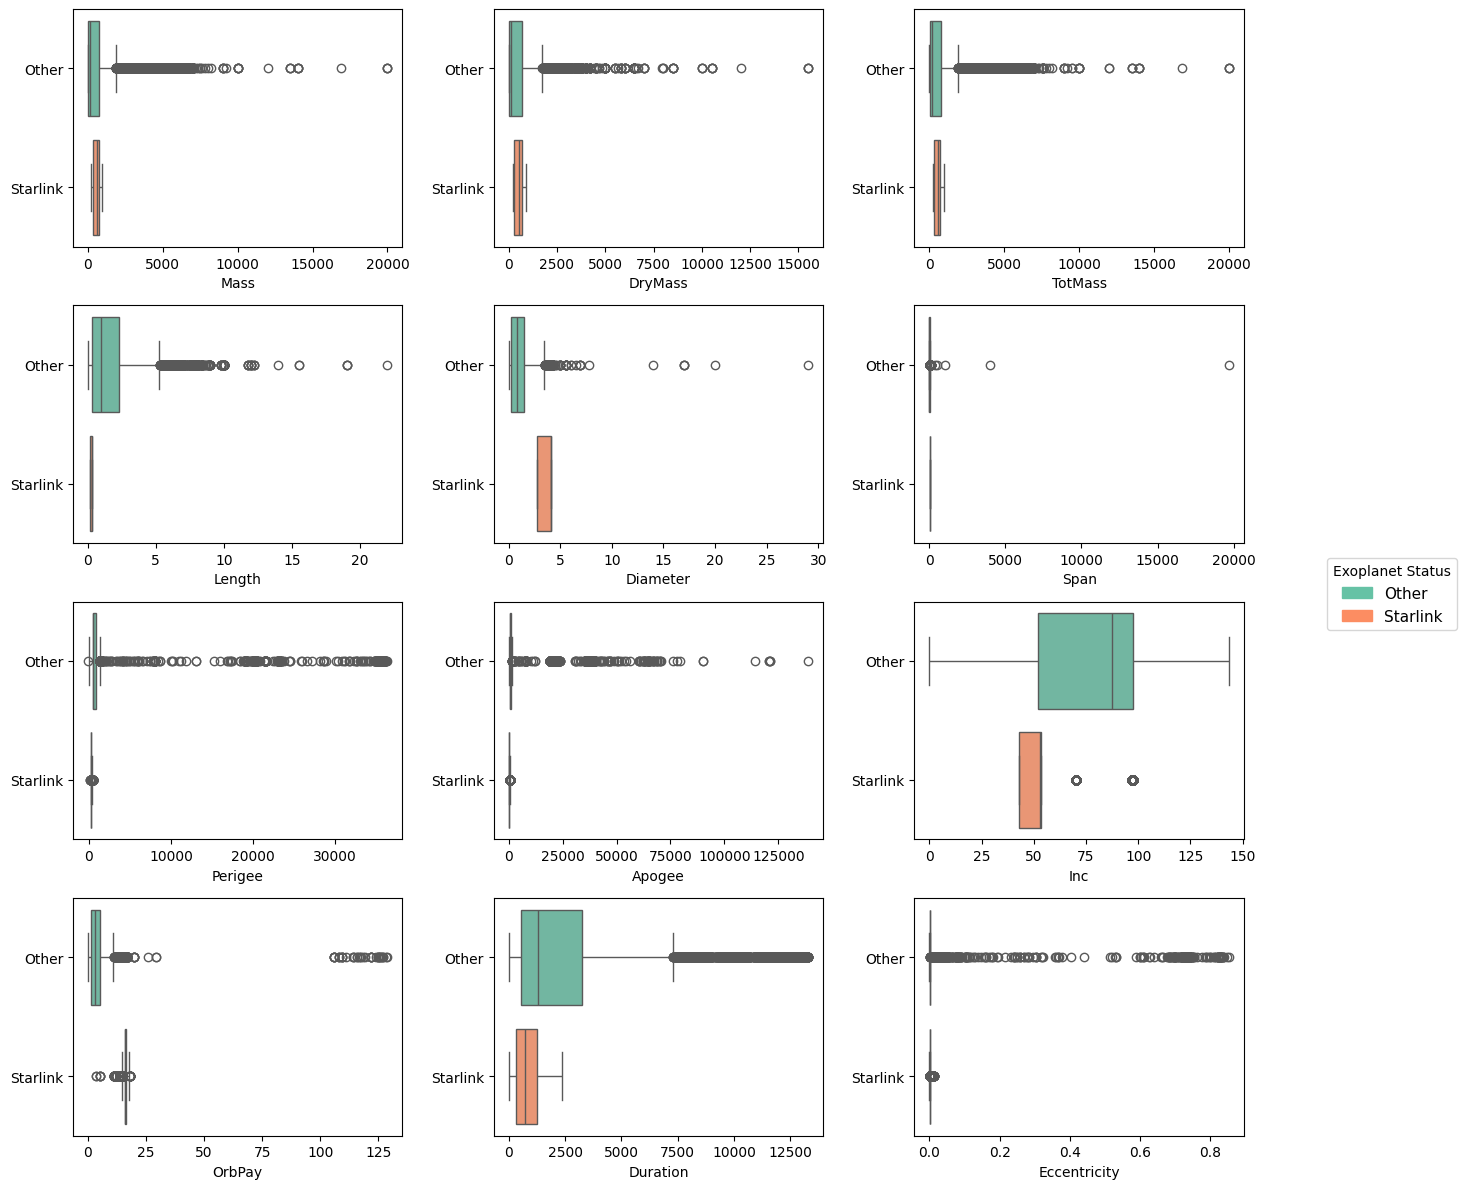

In [141]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns
numeric_columns=numeric_columns.drop(['Event', 'Final_Mass'])

# Creating a 4x4 grid of plots
fig, ax = plt.subplots(4, 3, figsize=(15, 12))

# Iterate through variables and create horizontal box plots
for var, subplot in zip(numeric_columns, ax.flatten()):
    # Correction: added hue='label' and legend=False to remove all FutureWarning
    sns.boxplot(
        x=var,
        y='Starlink',
        data=df_clean,
        hue='Starlink',
        ax=subplot,
        palette='Set2',
        legend=False
    )

    # Remove extra axis labels for clarity
    subplot.set_ylabel('')
    subplot.set_xlabel(var, fontsize=10)

# Safely hide unused cells if there are fewer than 16 features
for i in range(len(numeric_columns), 12):
    ax.flatten()[i].axis('off')

# Create a legend based on the last active plot instead of a 'broken' dummy_ax
# This completely solves the UserWarning problem
handles, labels = ax.flatten()[len(numeric_columns)-1].get_legend_handles_labels()

# If subplots did not return handles manually, collect them directly
if not handles:
    import matplotlib.patches as mpatches
    # Automatically collect colors from the Set2 palette for a nice legend
    colors = sns.color_palette('Set2', len(df_clean['Starlink'].unique()))
    handles = [mpatches.Patch(color=colors[i], label=label) for i, label in enumerate(df_clean['Starlink'].unique())]
    labels = list(df_clean['Starlink'].unique())

# Adjust for neat spacing
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Add a single nice legend on the right
fig.legend(handles, labels, loc='center right', title='Exoplanet Status', bbox_to_anchor=(0.98, 0.5), fontsize=11)

# Display the result
plt.show()

Starlink exhibits a highly distinct operational profile compared to other satellite owners:

Extreme Homogeneity: Starlink's distributions (Apogee, Perigee, Mass, and Length) are compressed. This reflects massive standardization - hundreds of identical mass satellites executing uniform, tightly controlled orbits.

Low Earth Orbit (LEO) Focus: Its altitude markers (Apogee/Perigee) sit uniformly at the bottom of the scale.

The "Others" Contrast: In contrast, other operators display massive variance, long heavily skewed tails, and extreme outliers, representing a highly fragmented mix of massive geostationary hardware and diverse orbital trajectories.

# Correlation

### Spearman Rank Correlation for Continuous Features

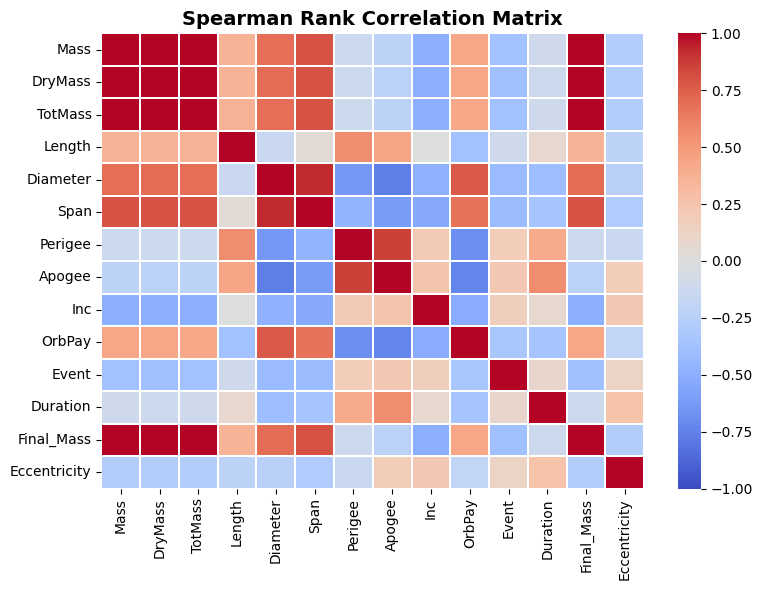

In [142]:
# 1. Calculate correlation strictly for numeric columns (numeric_only=True)
# The 'spearman' method is better at catching non-linear dependencies (like between DryMass and Span)
corr_matrix = df_clean.corr(method='spearman', numeric_only=True)

# 2. Visualize
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    linewidths=0.1,
    vmax=1,
    vmin=-1,
    center=0
)

plt.title('Spearman Rank Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [143]:
def find_correlations(mat, threshold):
    # Keep only the upper triangle (excluding the diagonal) to avoid duplicates and self-correlation
    cor_pairs = mat.stack().reset_index()
    cor_pairs.columns = ['var1', 'var2', 'cor_value']

    # Ensure var1 < var2 to keep only one instance of each pair
    cor_pairs = cor_pairs[cor_pairs['var1'] < cor_pairs['var2']]

    # Filter by absolute correlation value
    highly_correlated_pairs = cor_pairs[abs(cor_pairs['cor_value']) > threshold]

    # Sort by absolute correlation value in descending order
    highly_correlated_pairs = highly_correlated_pairs.sort_values(by='cor_value', ascending=False, key=abs)

    return highly_correlated_pairs

# Find pairs with correlation > 0.5
highly_correlated = find_correlations(corr_matrix, threshold = 0.7)

print("Variable pairs with correlation coefficient above 0.7 (can lead to high VIF):\n")
highly_correlated

Variable pairs with correlation coefficient above 0.7 (can lead to high VIF):



,var1,var2,cor_value
26,DryMass,Final_Mass,1.000000
2,Mass,TotMass,0.999110
14,DryMass,Mass,0.996879
168,Final_Mass,Mass,0.996879
16,DryMass,TotMass,0.995553
170,Final_Mass,TotMass,0.995553
61,Diameter,Span,0.923435
104,Apogee,Perigee,0.861501
19,DryMass,Span,0.800316
173,Final_Mass,Span,0.800316


In [144]:
features_to_drop = [
    'Apogee',                         # Duplicates Perigee on circular orbits
    'Span',                           # Duplicates DryMass and geometry
    'Mass', 'TotMass', 'Final_Mass',  # Absolute collinear duplicates of DryMass
    'OrbPay'                          # Duplicates apparatus class and is collinear with diameter
]

df_clean = df_clean.drop(columns=[col for col in features_to_drop if col in df_clean.columns], axis=1)
corr_matrix = df_clean.corr(method='spearman', numeric_only=True)

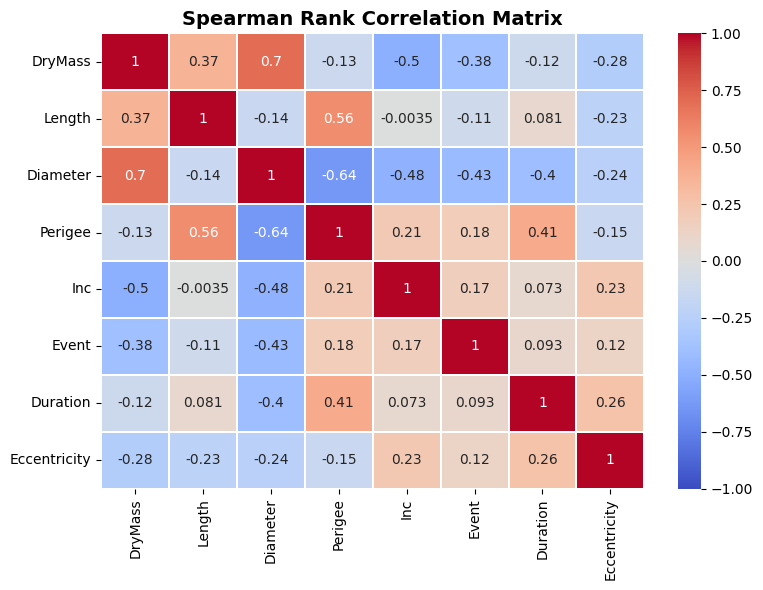

In [145]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.1,
    vmax=1,
    vmin=-1,
    center=0
)

plt.title('Spearman Rank Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Variance Inflation Factor

In [146]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Select only NUMERIC columns, as VIF cannot handle strings and dates
X_numeric = df_clean.select_dtypes(include=[np.number]).copy()

# 2. Drop targets (survival data) and features we decided to exclude
drop_cols = ['Duration', 'Event']
X_for_vif = X_numeric.drop(columns=drop_cols, errors='ignore')

# 3. Clean rows from NaN
X_for_vif = X_for_vif.dropna()

# 4. Add a constant (intercept) — this is a strict requirement for VIF mathematics
X_vif_with_const = sm.add_constant(X_for_vif)

# 5. Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X_vif_with_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_with_const.values, i)
    for i in range(len(X_vif_with_const.columns))
]

# Remove the constant row from the final output so it doesn't confuse (it always has a high VIF)
vif_data = vif_data[vif_data["feature"] != "const"].reset_index(drop=True)

print("\nMulticollinearity (VIF) analysis for the cleaned model:\n")
print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))


Multicollinearity (VIF) analysis for the cleaned model:

     feature      VIF
      Length 3.504569
     DryMass 2.868822
     Perigee 2.572775
         Inc 2.163069
    Diameter 1.944003
Eccentricity 1.150608


### Cramér's V Matrix for Nominal Features

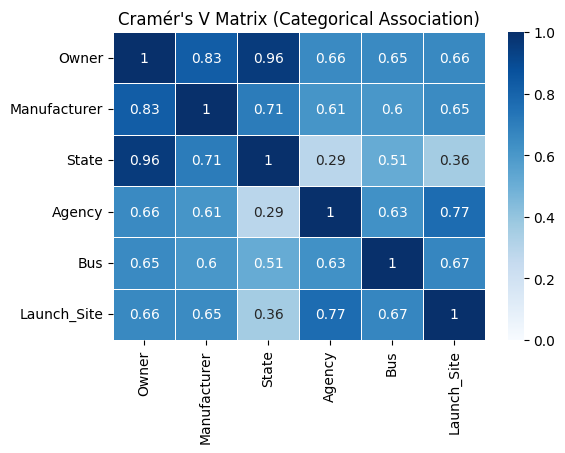

In [147]:
def cramers_v(x, y):
    """ Calculates Cramer's V coefficient between two categorical features """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    # Bias correction for small samples
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# List of your categorical columns (specify exact names from your df_clean)
cat_features = ['Owner', 'Manufacturer', 'State', 'Agency', 'Bus', 'Launch_Site']

# Build the association matrix
v_matrix = pd.DataFrame(index=cat_features, columns=cat_features, dtype=float)

for col1 in cat_features:
    for col2 in cat_features:
        if col1 == col2:
            v_matrix.loc[col1, col2] = 1.0
        else:
            v_matrix.loc[col1, col2] = cramers_v(df_clean[col1], df_clean[col2])

# Visualization

plt.figure(figsize=(6, 4))
sns.heatmap(v_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, linewidths=0.5)
plt.title('Cramér\'s V Matrix (Categorical Association)')
plt.show()

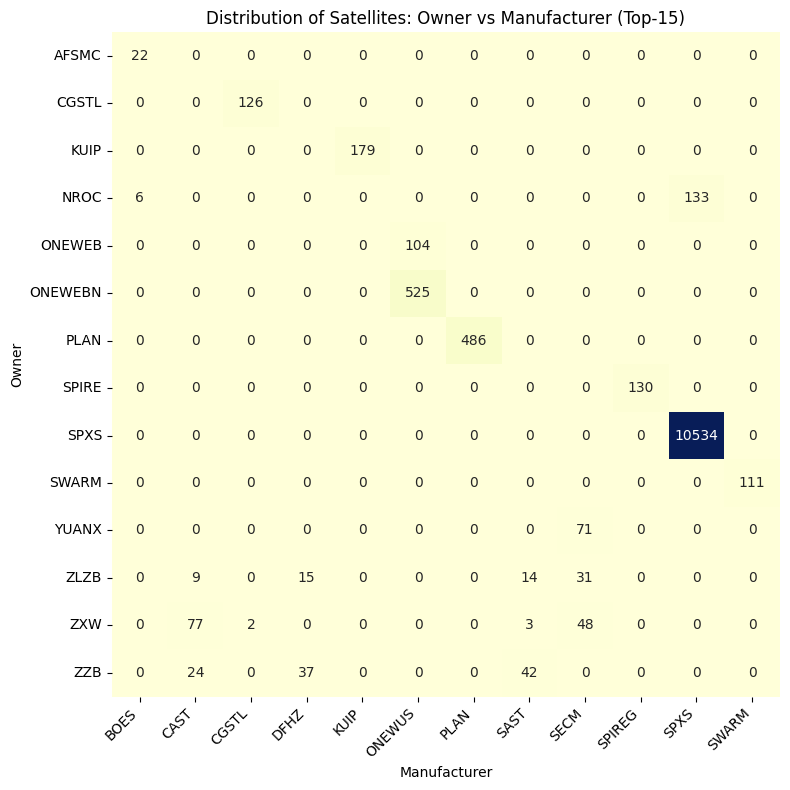

In [148]:
# Build a contingency table between Owner and Manufacturer
# Take, for example, the top-15 largest to avoid overloading the chart
top_owners = df_clean['Owner'].value_counts().nlargest(15).index
top_manufacturers = df_clean['Manufacturer'].value_counts().nlargest(15).index

filtered_df = df_clean[df_clean['Owner'].isin(top_owners) & df_clean['Manufacturer'].isin(top_manufacturers)]

ct = pd.crosstab(filtered_df['Owner'], filtered_df['Manufacturer'])

plt.figure(figsize=(8, 8))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu', cbar=False)
plt.title('Distribution of Satellites: Owner vs Manufacturer (Top-15)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [149]:
df_clean = df_clean.drop(columns=['Manufacturer','State'])

# Feature Engineering

**1. Target variables**. These two columns are passed to the model as a pair (Event, Duration):

* Duration - satellite lifetime in days (continuous time axis).
* Event - status (1 - deorbited/broken, 0 - alive/censored).

**2. Quantitative features.** RSF finds non-linear dependencies and threshold values in them.

* Perigee / Apogee / Inc (Perigee, Apogee, Inclination). Orbital parameters, determining atmospheric and radiation effects.

* OrbPay (Payload mass) or Final_Mass / DryMass / Mass / TotMass - choose one or two of the most populated columns with mass (highly correlated, choose DryMass and OrbPay).

* Length / Diameter / Span - geometric dimensions. Proxies for 'sail area' and apparatus size.

**3. Categorical features (Factors)** In Python (scikit-survival) these will need to be converted to numbers via pd.get_dummies().

* Category (Mission type: Sat LEO, Sat GEO, etc.) — a marker of operating conditions.

* OpOrbit (Operating orbit) - a companion to precise perigee/apogee numbers.

* Agency / Owner / State - who operates and which country. Choose one, maximum two, otherwise they will duplicate each other.

* LV_Type (Launch Vehicle) - reliability and launch accuracy.

* Launch_Site (Cosmodrome) - geographical marker.

* Manufacturer / Bus (Manufacturer / Space Platform) — an indicator of 'hardware' reliability.

* Shape (Apparatus shape: Box, Cyl) - affects aerodynamics in the upper atmosphere.

**4. What needs to be REMOVED (Not features for RSF)**
These columns are either unique IDs, duplicate target variables, or contain garbage flags:

Unique text IDs (will lead to overfitting): '**#JCAT', Satcat, Launch_Tag, Piece, Name, PLName, Parent, AltNames**.

Dates (the model cannot work with dates directly): **LDate, SDate, ODate, DDate1.**.

Data quality flags (usually text characters or emptiness): MassFlag, DryFlag, TotFlag, LFlag, DFlag, SpanFlag, Apoflag, RangeFlag, OQUAL.

Technical statuses and error codes: Status, Dest, Motor (too many unique engine types), FailCode, LaunchCode (if rocket accidents are filtered, all will have OS, i.e., zero variance).

In [150]:
df_clean.columns

Index(['#JCAT', 'Satcat', 'Launch_Tag', 'Piece', 'Type', 'Name', 'PLName',
       'LDate', 'Parent', 'SDate', 'Primary', 'Status', 'Owner', 'Bus',
       'DryMass', 'Length', 'Diameter', 'Shape', 'ODate', 'Perigee', 'Inc',
       'OpOrbit', 'Agency', 'LaunchCode', 'Category', 'Launch_Site',
       'Launch_Pad', 'LV_Type', 'DDate1', 'Event', 'Duration', 'MassClass',
       'Starlink', 'Eccentricity'],
      dtype='object')

In [151]:
df_clean.shape

(18987, 34)

In [152]:
columns_to_drop=['#JCAT', 'Satcat', 'Launch_Tag', 'Piece', 'Type', 'PLName', 'Parent', 'SDate','ODate', 'LaunchCode','DDate1', 'MassClass']
dataset=df_clean.drop(columns_to_drop,axis=1)
dataset['LDate'] = pd.to_datetime(dataset['LDate'])
dataset['Year']=dataset['LDate'].dt.year
dataset.shape

(18987, 23)

In [153]:
dataset.head().T

,0,1,2,3,4
Name,Skynet 4A,JCSAT 2,Leasat 5,Kosmos-2056,SPOT 2
LDate,1990-01-01 00:00:00,1990-01-01 00:00:00,1990-01-09 00:00:00,1990-01-18 00:00:00,1990-01-22 00:00:00
Primary,Earth,Earth,Earth,Earth,Earth
Status,N,O,N,O,O
Owner,MOD,JCSAT,HCI,UNKS,CNES
Bus,ECS,HS-393,HS-381,Strela-2M,SPOT
DryMass,615.0,1100.0,1230.0,800.0,1750.0
Length,2.1,10.0,4.0,3.0,4.5
Diameter,1.9,3.6,4.3,2.0,2.0
Shape,Box + 2 Pan,Cyl,Cyl + Ant,Cyl,Box + Pan


In [154]:
for col in dataset.select_dtypes(include=['object']).columns:
    dataset[col] = dataset[col].astype(str).str.strip()

In [155]:
# Let's write a loop that neatly displays information for each column
for col in dataset.columns:
    print(f"\n=========================================")
    print(f" COLUMN: {col} | Type: {dataset[col].dtype}")
    print(f" Missing values (NaN): {dataset[col].isna().sum()} ({dataset[col].isna().mean()*100:.1f} %)")
    print(f" Total unique values: {dataset[col].nunique()}")
    print(f"=========================================")

    # If the column is numeric and has too many unique values (e.g., Perigee or Mass)
    if dataset[col].dtype in ['int64', 'float64'] and dataset[col].nunique() > 10:
        # For numbers, it's better to show the general distribution instead of a long value_counts list
        print(dataset[col].describe()[['mean', 'min', '50%', 'max']].to_string())
    else:
        # For categories, display the top-30 most frequent values (to avoid overwhelming the screen)
        print(dataset[col].value_counts(dropna=False).head(20))


 COLUMN: Name | Type: object
 Missing values (NaN): 0 (0.0 %)
 Total unique values: 18887
Name
Molniya-3                       16
Xingwang Jishu Shiyan W.        15
Gorizont                        13
Molniya-1                       10
Raduga                           9
Molniya-1T                       7
Raduga-1                         7
Nadezhda                         4
Cartosat-2 Series Satellite      4
Meteor-2                         3
Raduga-1M                        3
Digui Tongxin Shiyan Wei.        3
Meteor-3                         3
Luch                             2
COMPASS-2                        2
Harbinger                        2
Skykraft 4A                      2
Daqi Huanjing Jiance Weixing     2
MisrSat-2                        2
Stella                           2
Name: count, dtype: int64

 COLUMN: LDate | Type: datetime64[ns]
 Missing values (NaN): 0 (0.0 %)
 Total unique values: 2473
LDate
2021-01-24    136
2024-08-16    123
2025-11-28    123
2025-06-23    122
2

In [120]:
max_eccentricity_Starlink=dataset[dataset.Starlink=='Starlink']['Eccentricity'].max()
max_eccentricity_Starlink

0.011925119251192511

In [156]:
# Drop columns
dataset=dataset.drop(['Primary','Status','Launch_Pad','LV_Type', 'Category', 'Agency'], axis=1)

In [157]:
# NaN in OpOrbit
dataset['OpOrbit'] = dataset['OpOrbit'].fillna('Unknown')

## Aggregating data

In [158]:
import pandas as pd

def clean_satellite_shape_(shape_str):
    if pd.isna(shape_str):
        return 'Unknown'

    # Convert to lowercase and remove extra spaces, question marks
    s = str(shape_str).lower().replace(' ', '').replace('?', '')

    # Group by key geometry types
    if 'box+' in s or 'box' in s:
        if 'pan' in s or 'panel' in s:
            return 'Box_with_Panels'
        elif 'ant' in s or 'dish' in s:
            return 'Box_with_Antennas'
        else:
            return 'Pure_Box'

    elif 'cyl' in s:
        if 'pan' in s:
            return 'Cylinder_with_Panels'
        else:
            return 'Pure_Cylinder'

    elif 'sphere' in s:
        return 'Sphere'

    elif 'trapezoid' in s or 'prism' in s:
        return 'Complex_Prism_with_Panels'

    return 'Other'

# Apply cleaning and create a nicely ordered feature
dataset['Clean_Shape'] = dataset['Shape'].apply(clean_satellite_shape_)

# See the result
print(dataset['Clean_Shape'].value_counts())

Clean_Shape
Box_with_Panels              14806
Pure_Box                      1900
Complex_Prism_with_Panels      747
Cylinder_with_Panels           553
Pure_Cylinder                  392
Box_with_Antennas              353
Sphere                         118
Other                          118
Name: count, dtype: int64


In [159]:
import re

def clean_satellite_bus(bus_str):
    if pd.isna(bus_str):
        return 'Unknown'

    b = str(bus_str).strip().lower()

    # 1. Group all Starlinks (including Starshield) into one class
    if 'starlink' in b or 'starshield' in b:
        return 'Starlink_Platform'

    # 2. Standardize Cubesats by their units (U)
    if 'cubesat' in b:
        match = re.search(r'(\d+\.?\d*)u', b)
        if match:
            return f'Cubesat_{match.group(1)}U'
        return 'Cubesat_Other'

    # 3. Highlight other major mega-constellations
    if 'arrow' in b: # Platform for OneWeb
        return 'Arrow_Platform'
    if 'kuiper' in b:
        return 'Kuiper_Platform'

    # Group all other 1000+ rare platforms
    return 'Other_Platform'

# Apply the cleaning function
dataset['Clean_Bus'] = dataset['Bus'].apply(clean_satellite_bus)

# Display the clean and compact result
print(dataset['Clean_Bus'].value_counts())

Clean_Bus
Starlink_Platform    10671
Other_Platform        5091
Cubesat_3U            1181
Arrow_Platform         664
Cubesat_6U             417
Cubesat_1U             222
Cubesat_0.25U          207
Kuiper_Platform        179
Cubesat_2U              68
Cubesat_1.5U            66
Cubesat_16U             66
Cubesat_12U             65
Cubesat_8U              30
Cubesat_0.5U            19
Cubesat_0.3U            19
Cubesat_4U              11
Cubesat_Other           10
Cubesat_27U              1
Name: count, dtype: int64


In [160]:
def clean_satellite_owner(owner_str):
    if pd.isna(owner_str):
        return 'Unknown'

    # Convert to uppercase and remove extra spaces
    owner = str(owner_str).strip().upper()

    # List of main players we want to keep as is
    # Combine OneWeb into one class
    if owner in ['ONEWEBN', 'ONEWEB']:
        return 'ONEWEB'

    main_owners = [
        'SPXS',     # SpaceX (Starlink)
        'PLAN',     # Planet Labs
        'NROC',     # NRO (US Intelligence)
        'ZXW',      # China Satellite Network Group (Chinese Starlink)
        'KUIP',     # Project Kuiper (Amazon)
        'CGSTL',    # Chang Guang (Chinese commercial Earth observation)
        'SPIRE',    # Spire Global
        'ZZB',      # China Strategic Support Force (Chinese Military)
        'SWARM',    # Swarm Technologies (Internet of Things)
        'PVO',      # Russian Aerospace Forces (in historical records)
        'YUANX',    # Chinese experimental series
        'ZLZB',     # Chinese intelligence agencies
        'AFSMC',    # US Air Force Space Command (now Space Force)
        'ISRO',     # Indian Space Agency
        'CNSA',     # China National Space Administration
        'VKS',      # Russian Aerospace Forces
        'CASC',     # China Aerospace Science and Technology Corporation
        'IRIDS'     # Iridium (Famous satellite communication network)
    ]

    if owner in main_owners:
        return owner

    # All other 1500 small operators are sent to "Others"
    return 'Other_Owners'

# Create a new cleaned column
dataset['Clean_Owner'] = dataset['Owner'].apply(clean_satellite_owner)

# Check how compact and neat the list has become
print(dataset['Clean_Owner'].value_counts())

Clean_Owner
SPXS            10534
Other_Owners     5502
ONEWEB            635
PLAN              486
NROC              192
ZXW               184
KUIP              179
CGSTL             146
SPIRE             131
ZZB               113
SWARM             111
PVO               108
YUANX             102
AFSMC              87
ZLZB               87
ISRO               85
CNSA               83
VKS                77
CASC               75
IRIDS              70
Name: count, dtype: int64


In [161]:
def clean_satellite_manufacturer(man_str):
    if pd.isna(man_str):
        return 'Unknown'

    # Convert to uppercase, remove spaces and question marks
    m = str(man_str).strip().upper().replace('?', '')

    # Merge obvious duplicates of mega-constellation manufacturers
    if m.startswith('SWARM'):
        return 'SWARM'
    if m == 'ONEWUS':
        return 'ONEWEB_US' # Joint factory of OneWeb and Airbus in the USA
    if m == 'SPIREG':
        return 'SPIRE'

    # Top manufacturers of space technology (USA, Europe, China, Russia, India)
    main_manufacturers = [
        'SPXS',   # SpaceX
        'PLAN',   # Planet Labs
        'CAST',   # China Academy of Space Technology (Main manufacturer of China)
        'CGSTL',  # Chang Guang (China)
        'SECM',   # Chinese defense factories
        'KUIP',   # Amazon Kuiper
        'DFHZ',   # DFH Satellite Co (China)
        'RESH',   # JSC "Reshetnev" (Information Satellite Systems, Russia)
        'LOR',    # Loral Space & Communications
        'NPOPM',  # NPO of Applied Mechanics (historical name of Reshetnev)
        'SAST',   # Shanghai Academy of Spaceflight Technology
        'BOES',   # Boeing Space & Intelligence Systems
        'NPOPMR', # Another modification of NPO PM / Reshetnev records
        'SPUT',   # Sputnix (Russian private cubesat manufacturer)
        'POL',    # Polytechnic Institutes / Universities of China
        'HSES',   # Harbin Institute of Technology (China)
        'UTIAS',  # University of Toronto (Canada)
        'GWCG',   # China Satellite Network Group
        'ICEYE',  # Finnish ICEYE radar satellites
        'THALES', # Thales Alenia Space (Europe)
        'URUGUS', # Satellogic (Argentina/USA)
        'YUZH',   # Ukraine
        'DFHS',   # Dongfanghong Projects
        'ADST',   # Advanced Satellite Technology
        'OATKGA'  # Orbital ATK / Northrop Grumman
    ]

    if m in main_manufacturers:
        return m

    # All other small manufacturers are sent to one category
    return 'OTHER_MANUFACTURERS'

In [163]:
# Create a function that keeps the country if it's in the top 30, otherwise writes 'OTHERS'
def clean_satellite_state_top30(state_str):
    if pd.isna(state_str):
        return 'Unknown'

    s = str(state_str).strip().upper()

    if s in top_30_states:
        return s

    return 'OTHERS'

In [164]:
dataset.columns

Index(['Name', 'LDate', 'Owner', 'Bus', 'DryMass', 'Length', 'Diameter',
       'Shape', 'Perigee', 'Inc', 'OpOrbit', 'Launch_Site', 'Event',
       'Duration', 'Starlink', 'Eccentricity', 'Year', 'Clean_Shape',
       'Clean_Bus', 'Clean_Owner'],
      dtype='object')

In [165]:
dataset=dataset.drop(['Owner','Bus','Shape'], axis=1)

In [166]:
dataset = dataset.rename(columns={'Clean_Owner': 'Owner', 'Clean_Bus': 'Bus', 'Clean_Shape': 'Shape'})

In [167]:
dataset.head(10).T

,0,1,2,3,4,5,6,7,8,9
Name,Skynet 4A,JCSAT 2,Leasat 5,Kosmos-2056,SPOT 2,UoSAT-OSCAR-14,UoSAT-OSCAR-15,AMSAT-OSCAR-16,DOVE-OSCAR-17,WEBERSAT-OSCAR-18
LDate,1990-01-01 00:00:00,1990-01-01 00:00:00,1990-01-09 00:00:00,1990-01-18 00:00:00,1990-01-22 00:00:00,1990-01-22 00:00:00,1990-01-22 00:00:00,1990-01-22 00:00:00,1990-01-22 00:00:00,1990-01-22 00:00:00
DryMass,615.0,1100.0,1230.0,800.0,1750.0,46.0,47.0,10.0,12.0,12.0
Length,2.1,10.0,4.0,3.0,4.5,0.7,0.6,0.2,0.2,0.3
Diameter,1.9,3.6,4.3,2.0,2.0,0.4,0.4,0.2,0.2,0.2
Perigee,35449,35776,35264,775,824,786,786,787,787,788
Inc,3.37,0.26,3.36,74.04,98.72,98.71,98.71,98.72,98.72,98.71
OpOrbit,GEO/ID,GEO/S,GEO/I,LEO/I,LEO/S,LEO/S,LEO/S,LEO/S,LEO/S,LEO/S
Launch_Site,CC,CC,KSC,NIIP-53,CSG,CSG,CSG,CSG,CSG,CSG
Event,1,0,1,0,0,0,0,0,0,0


### Top 10 elongated orbits

In [170]:
dataset.sort_values('Eccentricity', ascending=False).head(10)

,Name,LDate,DryMass,Length,Diameter,Perigee,Inc,OpOrbit,Launch_Site,Event,Duration,Starlink,Eccentricity,Year,Shape,Bus,Owner
2115,SES-8,2013-12-03,1500.0,4.3,2.3,395,20.51,VHEO,CC,0,4553.0,Other,0.853517,2013,Box_with_Panels,Other_Platform,Other_Owners
1233,Tan Ce 1,2003-12-29,350.0,2.1,1.4,555,28.50,VHEO,XSC,1,1385.0,Other,0.848228,2003,Pure_Cylinder,Other_Platform,CASC
5980,Turksat 5B,2021-12-19,3500.0,4.5,3.0,198,27.12,HEO,CC,0,1615.0,Other,0.839382,2021,Box_with_Panels,Other_Platform,Other_Owners
2729,Inmarsat 5F4,2017-05-15,3700.0,7.0,3.2,384,24.52,GEO/NS,KSC,0,3294.0,Other,0.837563,2017,Box_with_Panels,Other_Platform,Other_Owners
12206,Turksat 6A,2024-07-08,1700.0,4.5,3.0,383,24.10,GEO/NS,CC,0,683.0,Other,0.836564,2024,Box_with_Panels,Other_Platform,Other_Owners
18880,SWC-1,2026-04-01,20.0,0.3,0.2,492,28.33,GEO/NS,KSC,0,51.0,Other,0.835400,2026,Pure_Box,Cubesat_12U,Other_Owners
3349,Arabsat 6A,2019-04-11,3520.0,3.9,2.4,2400,18.05,VHEO,KSC,0,2598.0,Other,0.833172,2019,Box_with_Panels,Other_Platform,Other_Owners
13931,Spainsat NG-1,2025-01-30,5500.0,6.7,2.7,471,26.82,HEO,KSC,0,477.0,Other,0.832442,2025,Box_with_Panels,Other_Platform,Other_Owners
2776,BulgariaSat-1,2017-06-23,3000.0,5.6,2.8,196,23.95,HEO,KSC,0,3255.0,Other,0.832105,2017,Box_with_Panels,Other_Platform,Other_Owners
5981,Inmarsat 6 F1,2021-12-22,4000.0,9.0,2.5,179,30.04,HEO,TNSC,0,1612.0,Other,0.831055,2021,Box_with_Panels,Other_Platform,Other_Owners


Inmarsat 5F4: (GEO/NS) https://spaceflightnow.com/2017/05/16/fourth-satellite-for-inmarsats-global-broadband-network-launched-by-spacex/

# Kaplan-Meier Estimator

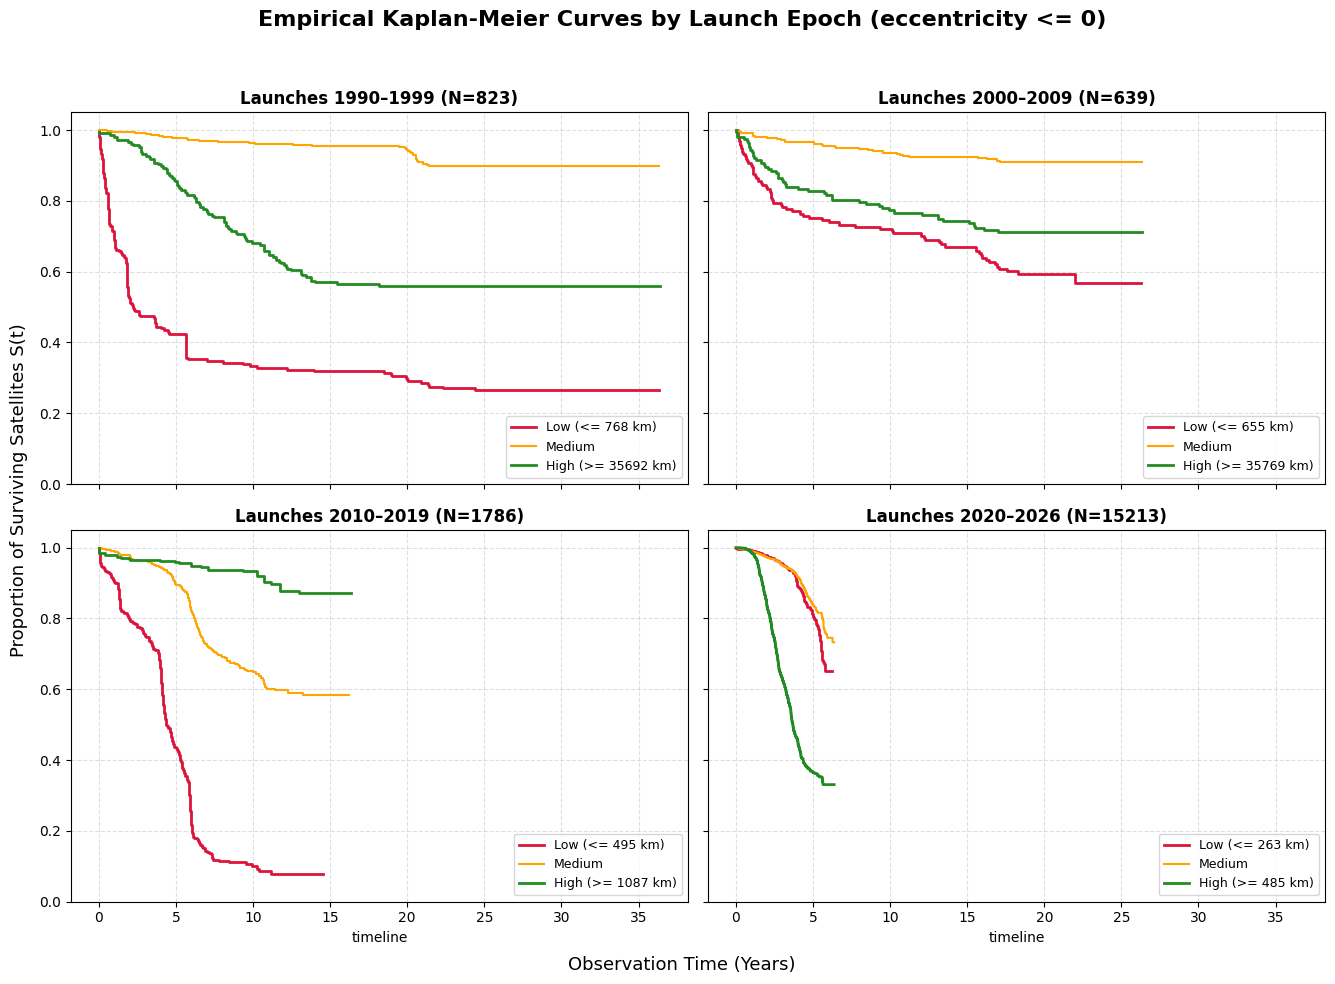

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

# 1. Prepare data: extract year from LDate and select necessary columns
df_km = df_clean.copy()
df_km['Launch_Year'] = pd.to_datetime(df_km['LDate']).dt.year

# Target column names
# Replace 'Status' and 'Duration'
status_col = 'Event'      # Binary flag (1 - deceased, 0 - alive/censored)
duration_col = 'Duration'  # Life time (X-axis)

# Convert duration from days to years
df_km['Duration_Years'] = df_km[duration_col] / 365.25
duration_col_plot = 'Duration_Years'

# Set up a 2x2 grid for plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Our historical breakdown
epochs = [
    ("1990–1999", 1990, 1999),
    ("2000–2009", 2000, 2009),
    ("2010–2019", 2010, 2019),
    ("2020–2026", 2020, 2026)
]

kmf = KaplanMeierFitter()

for i, (name, start_y, end_y) in enumerate(epochs):
    # Filter the original dataset: epoch + circular orbits
    epoch_mask = (df_km['Launch_Year'] >= start_y) & \
                 (df_km['Launch_Year'] <= end_y) & \
                  (df_km['Eccentricity'] <= max_eccentricity_Starlink) # Soft filter for historical epochs

    df_epoch = df_km[epoch_mask]

    if len(df_epoch) < 10:
        axes[i].text(0.5, 0.5, f"Not enough data for {name}", ha='center', va='center', fontsize=12)
        axes[i].set_title(f"Epoch: {name}")
        continue

    # Calculate perigee quantiles STRICTLY within the current epoch
    low_val = df_epoch['Perigee'].quantile(0.25)
    high_val = df_epoch['Perigee'].quantile(0.75)

    # Distribute satellites into three height groups
    df_low = df_epoch[df_epoch['Perigee'] <= low_val]
    df_high = df_epoch[df_epoch['Perigee'] >= high_val]
    df_mid = df_epoch[(df_epoch['Perigee'] > low_val) & (df_epoch['Perigee'] < high_val)]

    # Plot Kaplan-Meier curve for LOW perigee
    if len(df_low) > 0:
        kmf.fit(durations=df_low[duration_col_plot], event_observed=df_low[status_col], label=f"Low (<= {low_val:.0f} km)")
        kmf.plot_survival_function(ax=axes[i], ci_show=False, color="crimson", lw=2)

    # For MEDIUM perigee
    if len(df_mid) > 0:
        kmf.fit(durations=df_mid[duration_col_plot], event_observed=df_mid[status_col], label="Medium")
        kmf.plot_survival_function(ax=axes[i], ci_show=False, color="orange", lw=1.5)

    # For HIGH perigee
    if len(df_high) > 0:
        kmf.fit(durations=df_high[duration_col_plot], event_observed=df_high[status_col], label=f"High (>= {high_val:.0f} km)")
        kmf.plot_survival_function(ax=axes[i], ci_show=False, color="forestgreen", lw=2)

    # Subplot formatting
    axes[i].set_title(f"Launches {name} (N={len(df_epoch)})", fontsize=12, fontweight='bold')
    axes[i].grid(True, linestyle="--", alpha=0.4)
    axes[i].legend(fontsize=9, loc="lower right")
    axes[i].set_ylim(0, 1.05)

# Overall captions for the entire panel
fig.suptitle(f"Empirical Kaplan-Meier Curves by Launch Epoch (eccentricity <= {round(max_eccentricity_Starlink)})", fontsize=16, fontweight='bold', y=0.98)
fig.text(0.5, 0.02, "Observation Time (Years)", ha='center', fontsize=13)
fig.text(0.02, 0.5, "Proportion of Surviving Satellites S(t)", va='center', rotation='vertical', fontsize=13)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.show()

### Starlink Histogram

In [188]:
min_year_starlink=dataset[(dataset['Starlink']=='Starlink')].Year.min()

In [189]:
starlink=dataset[(dataset['Starlink']=='Starlink') & (dataset['Year']>=min_year_starlink)]
starlink.Event.value_counts()

,count
Event,
0,9933
1,599


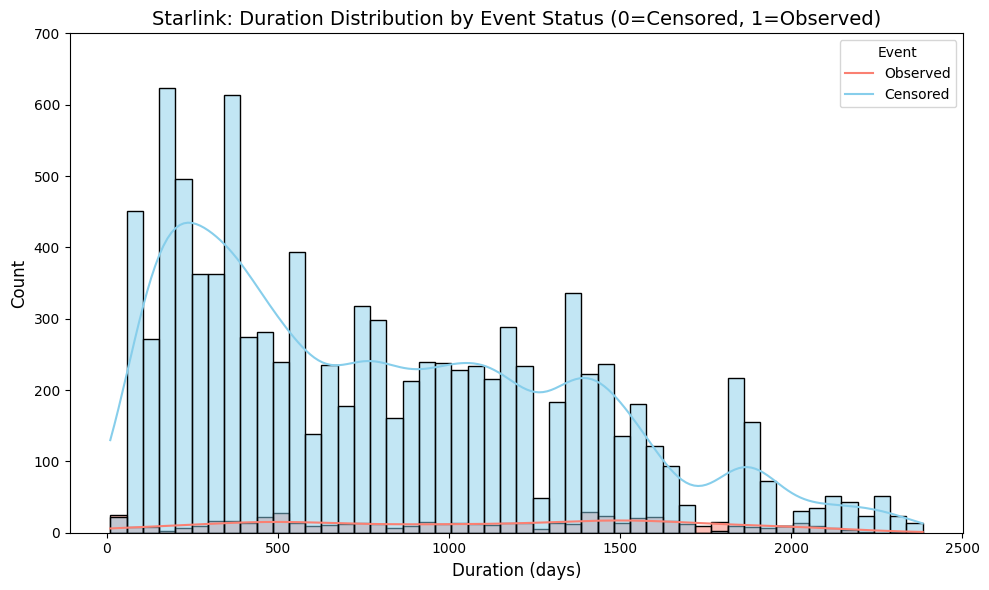

In [192]:
plt.figure(figsize=(10, 6))
sns.histplot(data=starlink, x='Duration', hue='Event', bins=50, kde=True, palette={0: 'skyblue', 1: 'salmon'})
plt.title('Starlink: Duration Distribution by Event Status (0=Censored, 1=Observed)', fontsize=14)
plt.xlabel('Duration (days)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ylim(0, 700)
plt.legend(title='Event', labels=['Observed', 'Censored'])
plt.tight_layout()
plt.show()

In [193]:
dataset.Owner.value_counts()

,count
Owner,
SPXS,10534
Other_Owners,5502
ONEWEB,635
PLAN,486
NROC,192
ZXW,184
KUIP,179
CGSTL,146
SPIRE,131


# Random Survival Forests

In [194]:
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored

# 1. Formulate lists of features

features = [
    'DryMass',
    'Perigee', 'Inc', 'Eccentricity',
    'OpOrbit', 'Launch_Site', 'Shape',
    'Bus', 'Owner', 'Starlink'
]

# Extract the feature matrix (X)
X = dataset[features].copy()

# 2. One-Hot encoding of categorical variables
# drop_first=True saves from extra collinearity of categories
X_encoded = pd.get_dummies(X, drop_first=True)

# Fill any random NaNs with medians (RSF cannot handle missing values)
X_encoded = X_encoded.fillna(X_encoded.median())

# 3. Prepare the target (y) for scikit-survival specifics
# It needs a structured numpy array with fields (Status, Time)
y = np.array(
    list(zip(dataset['Event'].astype(bool), dataset['Duration'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)

# 4. Split into training and testing samples (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("--- Starting RSF training (this may take a few minutes) ---")

# 5. Model initialization and training
# n_estimators=100 - base ensemble of 100 trees
# min_samples_split=10 and min_samples_leaf=5 protect against overfitting on noise

rsf = RandomSurvivalForest(
    n_estimators=100,
    min_samples_split=10,
    min_samples_leaf=5,
    n_jobs=-1,        # use all Colab processor cores
    random_state=42
)

rsf.fit(X_train, y_train)

# 6. Model quality evaluation via C-index (Concordance Index)
# 0.5 - random guessing, 1.0 - ideal prediction of death order
train_c_index = rsf.score(X_train, y_train)
test_c_index = rsf.score(X_test, y_test)

print("=================================================")
print(f"C-index on training set (Train): {train_c_index:.4f}")
print(f"C-index on test set (Test):  {test_c_index:.4f}")
print("=================================================")

Training set: (15189, 113)
Test set: (3798, 113)
--- Starting RSF training (this may take a few minutes) ---
C-index on training set (Train): 0.8886
C-index on test set (Test):  0.8707


## Feature Importance

In [195]:
from sksurv.metrics import concordance_index_censored

# 1. Automatically determine field names in your structured array y
status_field, duration_field = y_test.dtype.names
print(f"Fields defined in target: status = '{status_field}', time = '{duration_field}'")

X_sub = X_test.copy()
y_sub = y_test

print(f"Running step-by-step Permutation Importance on a sample of {len(X_sub)} rows...")

# 3. Calculate the base C-index of the model on the subsample
base_preds = rsf.predict(X_sub)
base_cindex = concordance_index_censored(y_sub[status_field], y_sub[duration_field], base_preds)[0]
print(f"Base C-index of the model on the subsample: {base_cindex:.4f}\n")

# 4. Run step-by-step feature traversal with logging
importances = {}
features = X_sub.columns.tolist()
total_features = len(features)

for idx, col in enumerate(features, 1):
    original_col = X_sub[col].copy()

    # Shuffle the feature
    X_sub[col] = np.random.permutation(X_sub[col].values)

    # Calculate score with the broken feature
    shuffled_preds = rsf.predict(X_sub)
    new_cindex = concordance_index_censored(y_sub[status_field], y_sub[duration_field], shuffled_preds)[0]

    # Calculate the delta of quality drop
    importances[col] = base_cindex - new_cindex

    X_sub[col] = original_col

    # Display status update every 10 features to see that the code is working
    if idx % 10 == 0 or idx == total_features:
        print(f"Progress: [{idx}/{total_features}] features processed... Current: {col}")

# 5. Collect results
importances_df = pd.DataFrame({
    'feature': importances.keys(),
    'weight': importances.values()
}).sort_values(by='weight', ascending=False)

Fields defined in target: status = 'Status', time = 'Time'
Running step-by-step Permutation Importance on a sample of 3798 rows...
Base C-index of the model on the subsample: 0.8707

Progress: [10/113] features processed... Current: OpOrbit_GTO
Progress: [20/113] features processed... Current: OpOrbit_LLEO/P
Progress: [30/113] features processed... Current: Launch_Site_GIK-1
Progress: [40/113] features processed... Current: Launch_Site_KASC
Progress: [50/113] features processed... Current: Launch_Site_PALB
Progress: [60/113] features processed... Current: Launch_Site_V
Progress: [70/113] features processed... Current: Shape_Box_with_Panels
Progress: [80/113] features processed... Current: Bus_Cubesat_1.5U
Progress: [90/113] features processed... Current: Bus_Cubesat_Other
Progress: [100/113] features processed... Current: Owner_NROC
Progress: [110/113] features processed... Current: Owner_ZLZB
Progress: [113/113] features processed... Current: Starlink_Starlink


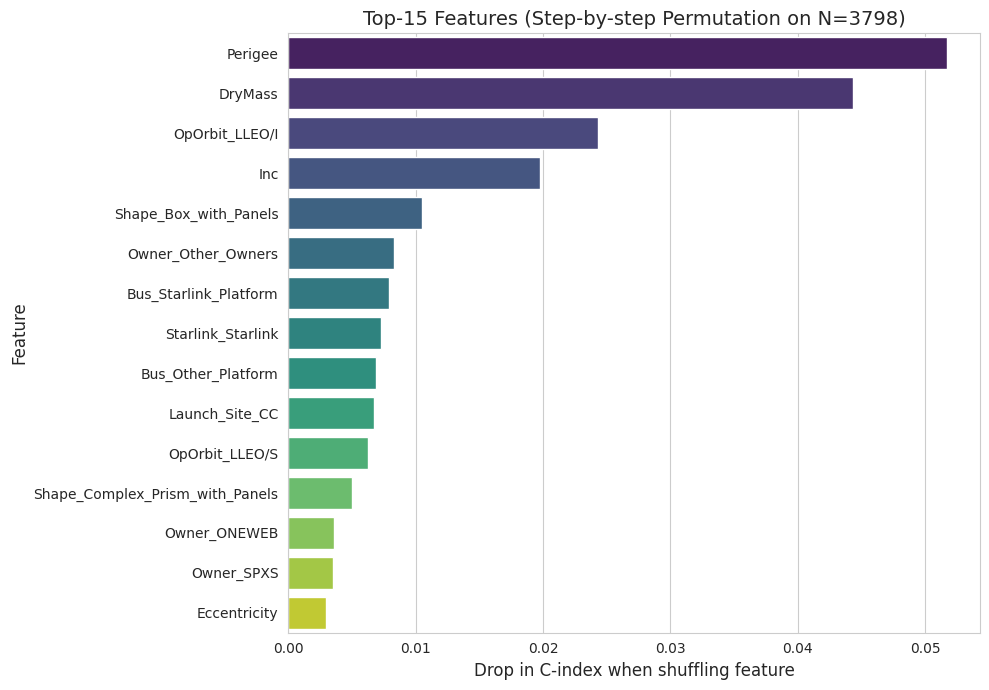


============== TOP-15 FEATURES ===============
                        feature   weight
                        Perigee 0.051713
                        DryMass 0.044359
                 OpOrbit_LLEO/I 0.024320
                            Inc 0.019729
          Shape_Box_with_Panels 0.010479
             Owner_Other_Owners 0.008300
          Bus_Starlink_Platform 0.007932
              Starlink_Starlink 0.007273
             Bus_Other_Platform 0.006849
                 Launch_Site_CC 0.006749
                 OpOrbit_LLEO/S 0.006222
Shape_Complex_Prism_with_Panels 0.004981
                   Owner_ONEWEB 0.003617
                     Owner_SPXS 0.003506
                   Eccentricity 0.002977


In [196]:
# Final graph for TOP-15
top_fi = importances_df.head(15)

sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))
sns.barplot(
    x="weight",
    y="feature",
    data=top_fi,
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title(f'Top-15 Features (Step-by-step Permutation on N={len(X_sub)})', fontsize=14)
plt.xlabel('Drop in C-index when shuffling feature', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\n============== TOP-15 FEATURES ===============")
print(top_fi.to_string(index=False))

## Partial Dependence Plots

### Numerical features

In [213]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_pdp = X_test.copy()

def calculate_pdp(feature_name, grid_points=30):
    """
    Calculates Partial Dependence values for a given feature
    """
    # Create a grid of values from the minimum to the 95th quantile (to prevent GEO from compressing the LEO graph to a point)
    # If it's perigee, the grid can be manually limited to 2500 km for LEO clarity,
    # or automatic selection can be left.
    if feature_name == 'Perigee':
        # Focus the grid on LEO/MEO (up to 2500 km) to analyze atmospheric physics
        grid = np.linspace(X_pdp[feature_name].min(), 2500, grid_points)
    else:
        grid = np.linspace(X_pdp[feature_name].min(), X_pdp[feature_name].quantile(0.95), grid_points)

    pdp_values = []

    # Temporary copy to avoid corrupting the original data
    X_temp = X_pdp.copy()

    for val in grid:
        # Strictly replace the feature value across the entire subsample
        X_temp[feature_name] = val

        # rsf.predict returns a risk score (the higher it is, the faster the satellite will 'die')
        preds = rsf.predict(X_temp)

        # Record the average risk across the entire sample for this feature value
        pdp_values.append(np.mean(preds))

    return grid, np.array(pdp_values)

# 2. Calculate dependencies
print("Calculating PDP for Perigee...")
perigee_grid, perigee_pdp = calculate_pdp('Perigee')

print("Calculating PDP for Dry Mass...")
mass_grid, mass_pdp = calculate_pdp('DryMass')

print("Calculating PDP for Inclination...")
inc_grid, inc_pdp = calculate_pdp('Inc')




Calculating PDP for Perigee...
Calculating PDP for Dry Mass...
Calculating PDP for Inclination...


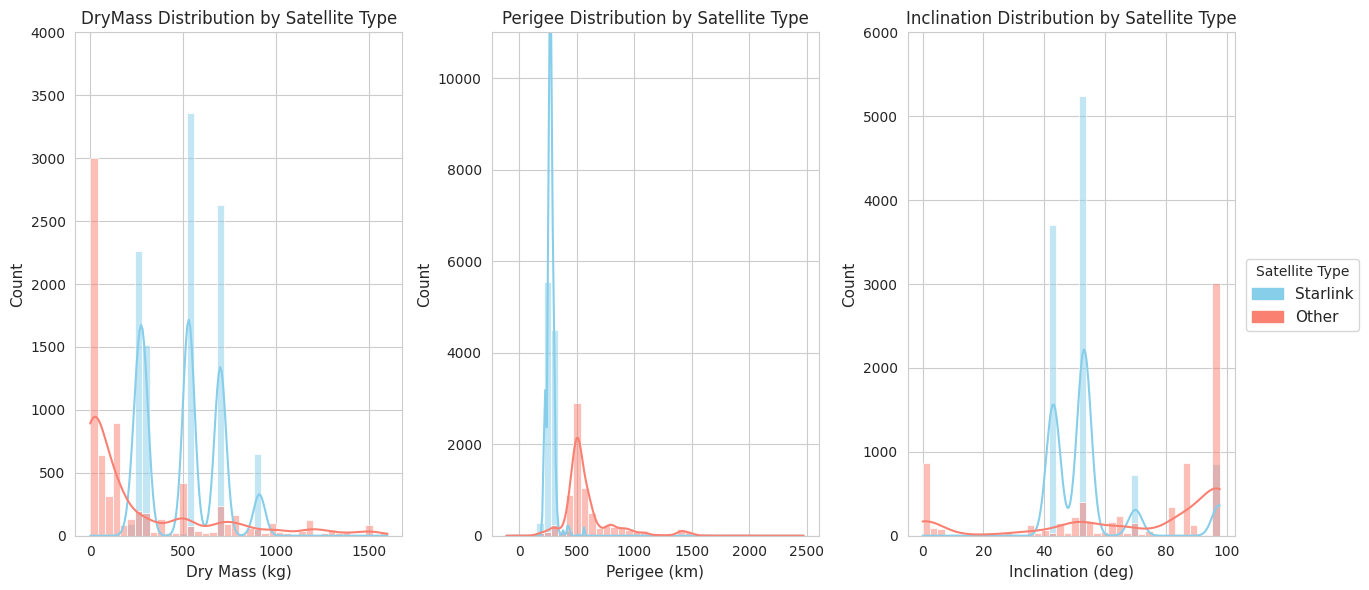

In [250]:
import matplotlib.patches as mpatches

data1=dataset[dataset.DryMass<=dataset.DryMass.quantile(0.95)]
data2=dataset[dataset.Perigee<=2500]
data3=dataset[dataset.Inc<=dataset.Inc.quantile(0.95)]
data1=data1.dropna()
data2=data2.dropna()
data3=data3.dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

sns.histplot(data=data1,x="DryMass",hue="Starlink",bins=40,kde=True,
    palette={"Starlink": "skyblue", "Other": "salmon"},ax=axes[0],legend=False)

axes[0].set_title("DryMass Distribution by Satellite Type", fontsize=12)
axes[0].set_xlabel("Dry Mass (kg)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_ylim(0, 4000)

sns.histplot(data=data2,x="Perigee",hue="Starlink",bins=40,kde=True,
    palette={"Starlink": "skyblue", "Other": "salmon"},ax=axes[1],legend=False)

axes[1].set_title("Perigee Distribution by Satellite Type", fontsize=12)
axes[1].set_xlabel("Perigee (km)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_ylim(0, 11000)

sns.histplot(data=data3,x="Inc",hue="Starlink",bins=40,kde=True,
    palette={"Starlink": "skyblue", "Other": "salmon"},ax=axes[2],legend=False)

axes[2].set_title("Inclination Distribution by Satellite Type", fontsize=12)
axes[2].set_xlabel("Inclination (deg)", fontsize=11)
axes[2].set_ylabel("Count", fontsize=11)
axes[2].set_ylim(0, 6000)

handles = [
    mpatches.Patch(color="skyblue", label="Starlink"),
    mpatches.Patch(color="salmon", label="Other"),
]

plt.tight_layout(rect=[0, 0, 0.9, 1])

fig.legend(
    handles=handles,
    title="Satellite Type",
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    fontsize=11,
)

plt.show()

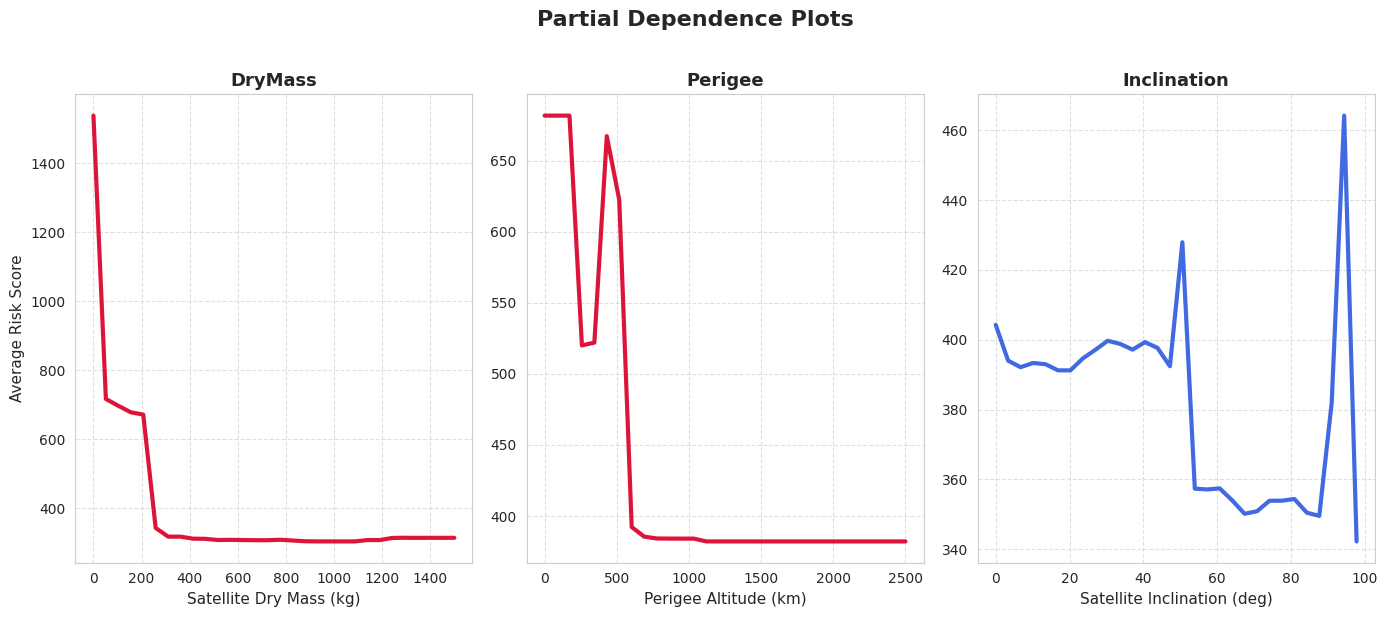

In [215]:
# 3. Visualization

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
axes = axes.flatten()

# Plot for Mass
axes[0].plot(mass_grid, mass_pdp, color='crimson', lw=3, label='PD Function')
axes[0].set_title('DryMass', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Satellite Dry Mass (kg)', fontsize=11)
axes[0].set_ylabel('Average Risk Score', fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot for Perigee
axes[1].plot(perigee_grid, perigee_pdp, color='crimson', lw=3, label='PD Function')
axes[1].set_title('Perigee', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Perigee Altitude (km)', fontsize=11)
#axes[1].set_ylabel('Average Risk Score', fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.6)

# Plot for Inclination
axes[2].plot(inc_grid, inc_pdp, color='royalblue', lw=3, label='PD Function')
axes[2].set_title('Inclination', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Satellite Inclination (deg)', fontsize=11)
#axes[2].set_ylabel('Average Risk Score', fontsize=11)
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.suptitle('Partial Dependence Plots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Non-Linear Risk Dynamics of Orbital Inclination

The Partial Dependence Plot (PDP) for Inclination exhibits a highly volatile, non-monotonic profile, which reflects socio-technical and geographical launch constraints rather than pure astrodynamical degradation.

* The Concurrency Peaks ($\approx 53^{\circ}$ and $97^{\circ}$–$98^{\circ}$): The sharp localized risk spikes correspond precisely to the most heavily populated orbital shells in modern astronautics. The drop and subsequent spike near $53^{\circ}$ captures the operational signature of massive commercial LEO constellations (e.g., Starlink programmatic recycling).

* The Polar Volatility Zone ($>90^{\circ}$): The extreme fluctuations in the $90^{\circ}$–$98^{\circ}$ range are driven by the Sun-synchronous orbit (SSO) regime. This sector suffers from high mathematical variance in the model due to the co-existence of two radically different satellite classes sharing identical geometric channels: highly vulnerable, non-propulsive academic CubeSats and long-lived institutional remote sensing platforms.

Consequently, the RSF model treats Inclination as a high-fidelity proxy for institutional mission intent and fleet deployment strategies, mapping specific operational risk architectures to rigid, discrete launch windows.

Based on the distribution and Partial Dependence Plots (PDP), the model is heavily leveraging deterministic constellation specifications rather than discovering smooth physical degradation laws:

* The Perigee-Starlink Match: The PDP for Perigee exhibits a massive risk drop immediately after 500–550 km. This directly mirrors the training data distribution, where Starlink satellites are densely packed around a perigee of 300–400 km, while non-Starlink payloads dominate the slightly higher altitudes.

* The Inclination Arbitrage: A similar artifact appears in the Inclination PDP. The risk score plunges abruptly near 53° and spikes heavily near 97°–98°. This perfectly corresponds to Starlink’s massive orbital shell configurations (predominantly 53° inclination) versus traditional sun-synchronous orbits (SSO) used by "Other" operators near 98°.

Conclusion: The Random Forest model is using these exact structural thresholds to separate the highly standardized Starlink fleet from the rest of the dataset, effectively tracking operational design choices rather than general orbital mechanics.

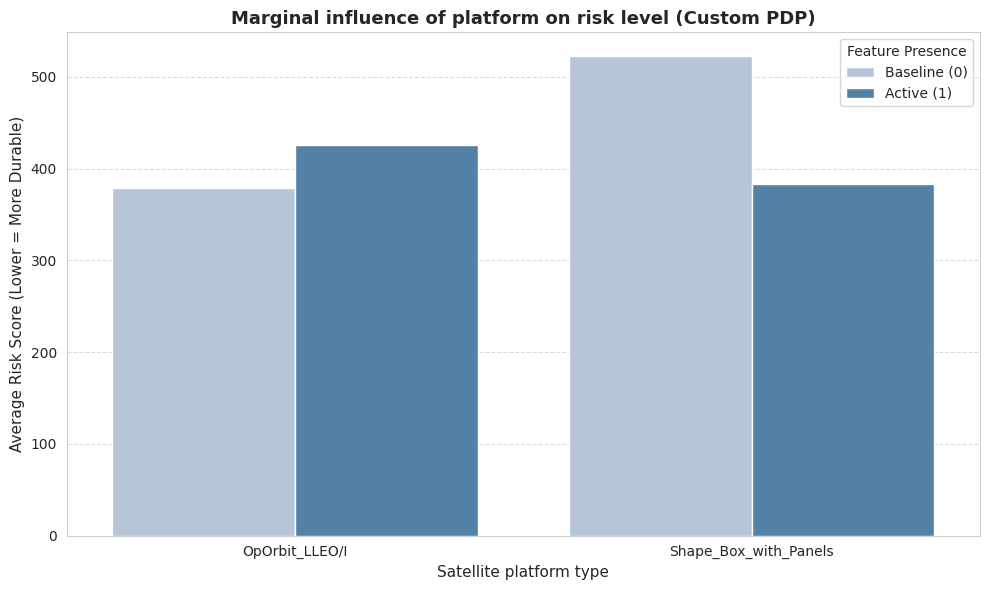

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_binary_pdp(model, X_data, feature_name):
    """ Manually calculates the average marginal risk for 0 and 1 """
    # Create two copies of the dataset
    X_0 = X_data.copy()
    X_1 = X_data.copy()

    # Force set the feature value to zero and one for ALL objects
    X_0[feature_name] = 0
    X_1[feature_name] = 1

    # Get model predictions (integral risk)
    # For scikit-survival, this is usually the predict() method
    risk_0 = model.predict(X_0).mean()
    risk_1 = model.predict(X_1).mean()

    return risk_0, risk_1

# Collect data for all platforms of interest
features = ['OpOrbit_LLEO/I', 'Shape_Box_with_Panels']
pdp_results = []

for feature in features:
    r0, r1 = calculate_binary_pdp(rsf, X_test, feature)
    pdp_results.append({'Platform': feature.replace('Bus_', ''), 'Status': 'Baseline (0)', 'Risk': r0})
    pdp_results.append({'Platform': feature.replace('Bus_', ''), 'Status': 'Active (1)', 'Risk': r1})

pdp_df = pd.DataFrame(pdp_results)

# Plot a comparative Barplot
plt.figure(figsize=(10, 6))
sns.barplot(
    data=pdp_df,
    x='Platform',
    y='Risk',
    hue='Status',
    palette=['#b0c4de', '#4682b4']
)

plt.title('Marginal influence of platform on risk level (Custom PDP)', fontsize=13, fontweight='bold')
plt.xlabel('Satellite platform type', fontsize=11)
plt.ylabel('Average Risk Score (Lower = More Durable)', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Feature Presence')
plt.tight_layout()
plt.show()

## Survival Plot

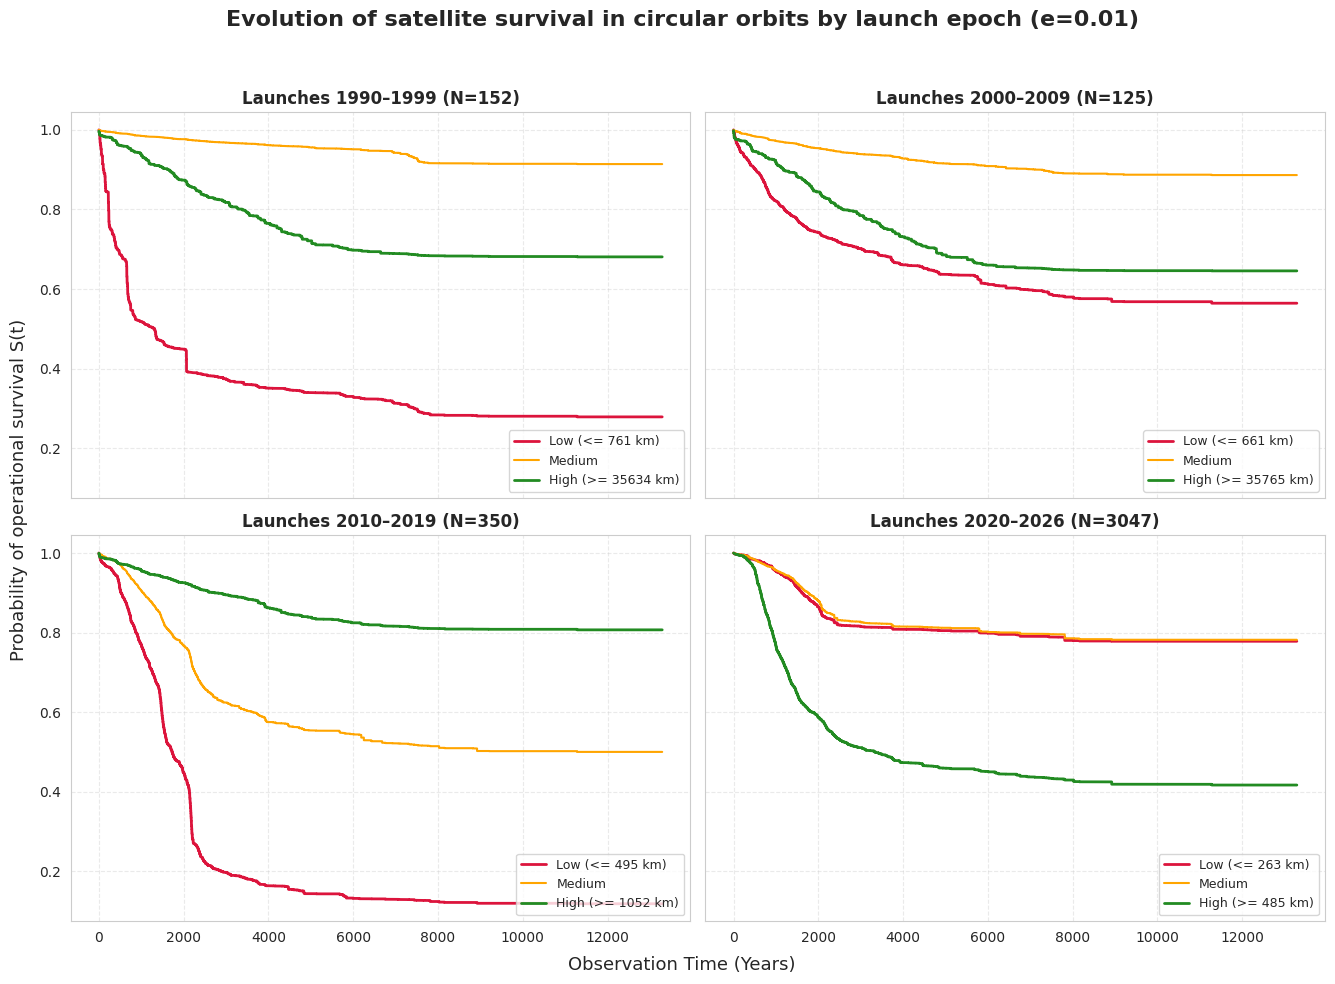

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming that in the original df_clean the year column is named 'Launch_Year'
# (if it's a full date, replace with pd.to_datetime(df_clean['Launch_Date']).dt.year)
X_test_with_year = X_test.copy()
X_test_with_year['Launch_Year'] = pd.to_datetime(df_clean.loc[X_test.index, 'LDate']).dt.year

# Set up a 2x2 grid for plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

# Define our 4 epochs (up to and including 2026)
epochs = [
    ("1990–1999", 1990, 1999),
    ("2000–2009", 2000, 2009),
    ("2010–2019", 2010, 2019),
    ("2020–2026", 2020, 2026)
]
# Get overall model predictions to calculate the time scale
surv_funcs = rsf.predict_survival_function(X_test)
times = surv_funcs[0].x

for i, (name, start_y, end_y) in enumerate(epochs):
    # Filter ONLY circular orbits within a specific epoch
    epoch_mask = (X_test_with_year['Launch_Year'] >= start_y) & \
                 (X_test_with_year['Launch_Year'] <= end_y) & \
                  (X_test_with_year['Eccentricity'] <= 0.01)

    X_epoch = X_test_with_year[epoch_mask]

    if len(X_epoch) < 10:
        axes[i].text(0.5, 0.5, f"Not enough data for {name}", ha='center', va='center')
        axes[i].set_title(f"Epoch: {name}")
        continue

    # Calculate perigee quantiles STRICTLY within this epoch
    low_val = X_epoch['Perigee'].quantile(0.25)
    high_val = X_epoch['Perigee'].quantile(0.75)

    idx_low = X_epoch[X_epoch['Perigee'] <= low_val].index
    idx_high = X_epoch[X_epoch['Perigee'] >= high_val].index
    idx_mid = X_epoch[(X_epoch['Perigee'] > low_val) & (X_epoch['Perigee'] < high_val)].index

    # Convert to positions for surv_funcs
    pos_low = [X_test.index.get_loc(idx) for idx in idx_low]
    pos_mid = [X_test.index.get_loc(idx) for idx in idx_mid]
    pos_high = [X_test.index.get_loc(idx) for idx in idx_high]

    # Average the curves
    surv_low = np.mean([f(times) for idx, f in enumerate(surv_funcs) if idx in pos_low], axis=0)
    surv_mid = np.mean([f(times) for idx, f in enumerate(surv_funcs) if idx in pos_mid], axis=0)
    surv_high = np.mean([f(times) for idx, f in enumerate(surv_funcs) if idx in pos_high], axis=0)

    # Plot subplot
    axes[i].step(times, surv_low, where="post", color="crimson", lw=2, label=f"Low (<= {low_val:.0f} km)")
    axes[i].step(times, surv_mid, where="post", color="orange", lw=1.5, label="Medium")
    axes[i].step(times, surv_high, where="post", color="forestgreen", lw=2, label=f"High (>= {high_val:.0f} km)")

    axes[i].set_title(f"Launches {name} (N={len(X_epoch)})", fontsize=12, fontweight='bold')
    axes[i].grid(True, linestyle="--", alpha=0.4)
    axes[i].legend(fontsize=9, loc="lower right")

# Overall captions for the entire grid
fig.suptitle("Evolution of satellite survival in circular orbits by launch epoch (e=0.01)", fontsize=16, fontweight='bold', y=0.98)
fig.text(0.5, 0.02, "Observation Time (Years)", ha='center', fontsize=13)
fig.text(0.02, 0.5, "Probability of operational survival S(t)", va='center', rotation='vertical', fontsize=13)

plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
plt.show()

## Without Starlink

In [294]:
other=dataset[(dataset['Starlink']=='Other')]
other.Event.value_counts()

,count
Event,
0,5985
1,2470


In [295]:
features = [
    'DryMass',
    'Perigee', 'Inc', 'Eccentricity',
    'Launch_Site', 'Shape',
    'Bus', 'Owner',
]

# Extract the feature matrix (X)
X = other[features].copy()

# 2. One-Hot encoding of categorical variables
# drop_first=True saves from extra collinearity of categories
X_encoded = pd.get_dummies(X, drop_first=True)

# Fill any random NaNs with medians (RSF cannot handle missing values)
X_encoded = X_encoded.fillna(X_encoded.median())

# 3. Prepare the target (y) for scikit-survival specifics
# It needs a structured numpy array with fields (Status, Time)
y = np.array(
    list(zip(other['Event'].astype(bool), other['Duration'])),
    dtype=[('Status', '?'), ('Time', '<f8')]
)

# 4. Split into training and testing samples (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("--- Starting RSF training (this may take a few minutes) ---")

# 5. Model initialization and training
# n_estimators=100 - base ensemble of 100 trees
# min_samples_split=10 and min_samples_leaf=5 protect against overfitting on noise

rsf = RandomSurvivalForest(
    n_estimators=100,
    max_depth=3,            # Ограничиваем глубину каждого дерева в лесу!
    min_samples_split=20,   # Узел не делится, если в нем мало объектов
    min_samples_leaf=10,    # В листе не может быть меньше 10 спутников
    n_jobs=-1,        # use all Colab processor cores
    random_state=42
)

rsf.fit(X_train, y_train)

# 6. Model quality evaluation via C-index (Concordance Index)
# 0.5 - random guessing, 1.0 - ideal prediction of death order
train_c_index = rsf.score(X_train, y_train)
test_c_index = rsf.score(X_test, y_test)

print("=================================================")
print(f"C-index on training set (Train): {train_c_index:.4f}")
print(f"C-index on test set (Test):  {test_c_index:.4f}")
print("=================================================")

Training set: (6764, 90)
Test set: (1691, 90)
--- Starting RSF training (this may take a few minutes) ---
C-index on training set (Train): 0.8113
C-index on test set (Test):  0.7956


In [261]:
from sksurv.metrics import concordance_index_censored

# 1. Automatically determine field names in your structured array y
status_field, duration_field = y_test.dtype.names
print(f"Fields defined in target: status = '{status_field}', time = '{duration_field}'")

X_sub = X_test.copy()
y_sub = y_test

print(f"Running step-by-step Permutation Importance on a sample of {len(X_sub)} rows...")

# 3. Calculate the base C-index of the model on the subsample
base_preds = rsf.predict(X_sub)
base_cindex = concordance_index_censored(y_sub[status_field], y_sub[duration_field], base_preds)[0]
print(f"Base C-index of the model on the subsample: {base_cindex:.4f}\n")

# 4. Run step-by-step feature traversal with logging
importances = {}
features = X_sub.columns.tolist()
total_features = len(features)

for idx, col in enumerate(features, 1):
    original_col = X_sub[col].copy()

    # Shuffle the feature
    X_sub[col] = np.random.permutation(X_sub[col].values)

    # Calculate score with the broken feature
    shuffled_preds = rsf.predict(X_sub)
    new_cindex = concordance_index_censored(y_sub[status_field], y_sub[duration_field], shuffled_preds)[0]

    # Calculate the delta of quality drop
    importances[col] = base_cindex - new_cindex

    X_sub[col] = original_col

    # Display status update every 10 features to see that the code is working
    if idx % 10 == 0 or idx == total_features:
        print(f"Progress: [{idx}/{total_features}] features processed... Current: {col}")

# 5. Collect results
importances_df = pd.DataFrame({
    'feature': importances.keys(),
    'weight': importances.values()
}).sort_values(by='weight', ascending=False)

Fields defined in target: status = 'Status', time = 'Time'
Running step-by-step Permutation Importance on a sample of 1691 rows...
Base C-index of the model on the subsample: 0.8804

Progress: [10/112] features processed... Current: OpOrbit_GTO
Progress: [20/112] features processed... Current: OpOrbit_LLEO/P
Progress: [30/112] features processed... Current: Launch_Site_GIK-1
Progress: [40/112] features processed... Current: Launch_Site_KASC
Progress: [50/112] features processed... Current: Launch_Site_PALB
Progress: [60/112] features processed... Current: Launch_Site_V
Progress: [70/112] features processed... Current: Shape_Box_with_Panels
Progress: [80/112] features processed... Current: Bus_Cubesat_1.5U
Progress: [90/112] features processed... Current: Bus_Cubesat_Other
Progress: [100/112] features processed... Current: Owner_NROC
Progress: [110/112] features processed... Current: Owner_ZLZB
Progress: [112/112] features processed... Current: Owner_ZZB


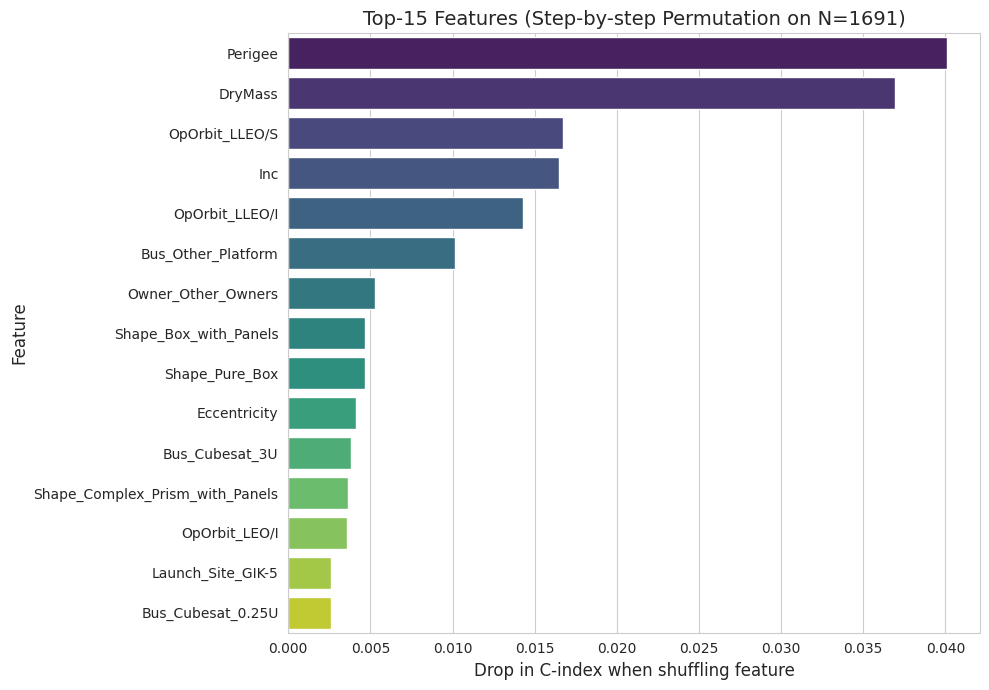


============== TOP-15 FEATURES ===============
                        feature   weight
                        Perigee 0.040099
                        DryMass 0.036942
                 OpOrbit_LLEO/S 0.016691
                            Inc 0.016467
                 OpOrbit_LLEO/I 0.014260
             Bus_Other_Platform 0.010172
             Owner_Other_Owners 0.005298
          Shape_Box_with_Panels 0.004677
                 Shape_Pure_Box 0.004665
                   Eccentricity 0.004147
                 Bus_Cubesat_3U 0.003825
Shape_Complex_Prism_with_Panels 0.003642
                  OpOrbit_LEO/I 0.003600
              Launch_Site_GIK-5 0.002622
              Bus_Cubesat_0.25U 0.002603


In [262]:
# Final graph for TOP-15
top_fi = importances_df.head(15)

sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))
sns.barplot(
    x="weight",
    y="feature",
    data=top_fi,
    hue="feature",
    palette="viridis",
    legend=False
)

plt.title(f'Top-15 Features (Step-by-step Permutation on N={len(X_sub)})', fontsize=14)
plt.xlabel('Drop in C-index when shuffling feature', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\n============== TOP-15 FEATURES ===============")
print(top_fi.to_string(index=False))

In [263]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

X_pdp = X_test.copy()

def calculate_pdp(feature_name, grid_points=30):
    """
    Calculates Partial Dependence values for a given feature
    """
    # Create a grid of values from the minimum to the 95th quantile (to prevent GEO from compressing the LEO graph to a point)
    # If it's perigee, the grid can be manually limited to 2500 km for LEO clarity,
    # or automatic selection can be left.
    if feature_name == 'Perigee':
        # Focus the grid on LEO/MEO (up to 2500 km) to analyze atmospheric physics
        grid = np.linspace(X_pdp[feature_name].min(), 2500, grid_points)
    else:
        grid = np.linspace(X_pdp[feature_name].min(), X_pdp[feature_name].quantile(0.95), grid_points)

    pdp_values = []

    # Temporary copy to avoid corrupting the original data
    X_temp = X_pdp.copy()

    for val in grid:
        # Strictly replace the feature value across the entire subsample
        X_temp[feature_name] = val

        # rsf.predict returns a risk score (the higher it is, the faster the satellite will 'die')
        preds = rsf.predict(X_temp)

        # Record the average risk across the entire sample for this feature value
        pdp_values.append(np.mean(preds))

    return grid, np.array(pdp_values)

# 2. Calculate dependencies
print("Calculating PDP for Perigee...")
perigee_grid, perigee_pdp = calculate_pdp('Perigee')

print("Calculating PDP for Dry Mass...")
mass_grid, mass_pdp = calculate_pdp('DryMass')

print("Calculating PDP for Inclination...")
inc_grid, inc_pdp = calculate_pdp('Inc')


Calculating PDP for Perigee...
Calculating PDP for Dry Mass...
Calculating PDP for Inclination...


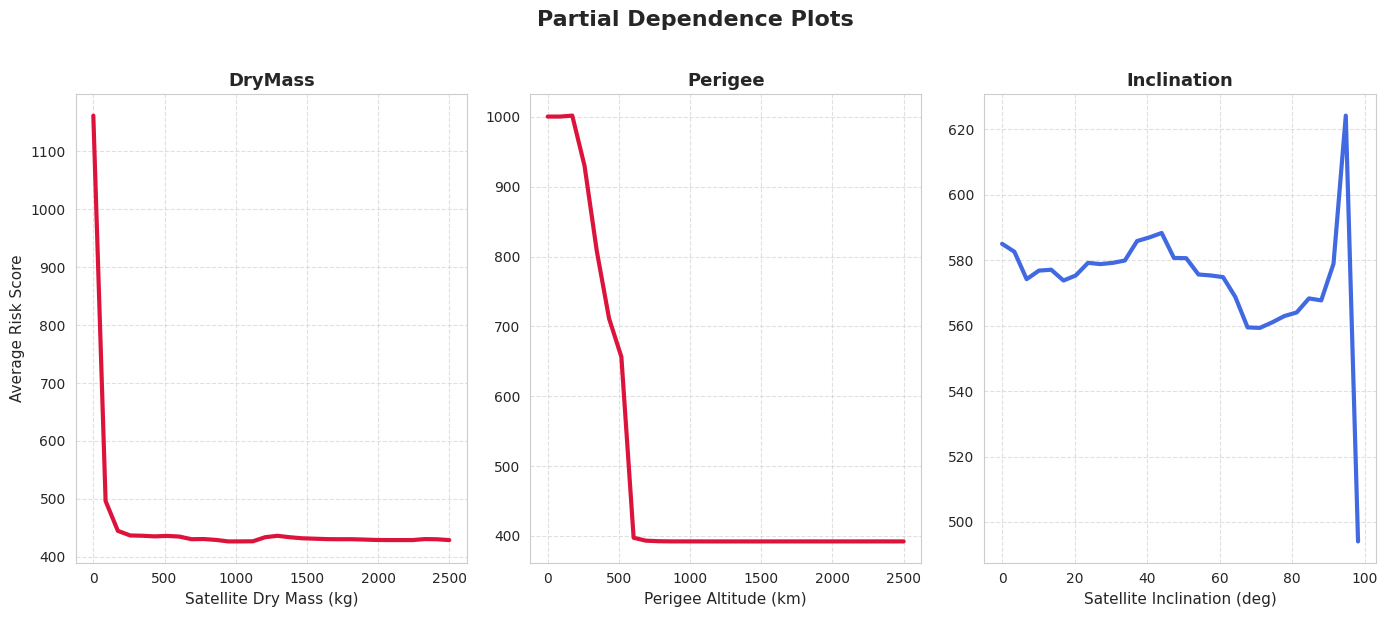

In [264]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
axes = axes.flatten()

# Plot for Mass
axes[0].plot(mass_grid, mass_pdp, color='crimson', lw=3, label='PD Function')
axes[0].set_title('DryMass', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Satellite Dry Mass (kg)', fontsize=11)
axes[0].set_ylabel('Average Risk Score', fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot for Perigee
axes[1].plot(perigee_grid, perigee_pdp, color='crimson', lw=3, label='PD Function')
axes[1].set_title('Perigee', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Perigee Altitude (km)', fontsize=11)
#axes[1].set_ylabel('Average Risk Score', fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.6)

# Plot for Inclination
axes[2].plot(inc_grid, inc_pdp, color='royalblue', lw=3, label='PD Function')
axes[2].set_title('Inclination', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Satellite Inclination (deg)', fontsize=11)
#axes[2].set_ylabel('Average Risk Score', fontsize=11)
axes[2].grid(True, linestyle="--", alpha=0.6)

plt.suptitle('Partial Dependence Plots', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

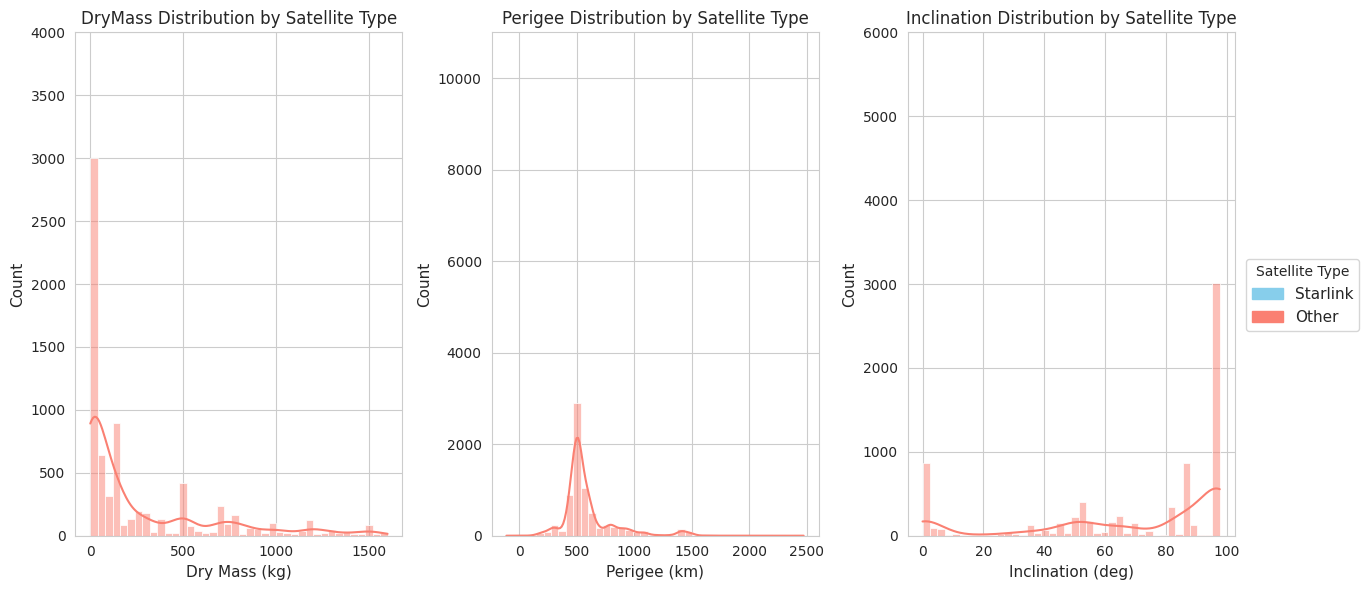

In [267]:
import matplotlib.patches as mpatches

data1=dataset[(dataset.DryMass<=dataset.DryMass.quantile(0.95)) & (dataset.Starlink=='Other')]
data2=dataset[(dataset.Perigee<=2500) & (dataset.Starlink=='Other')]
data3=dataset[(dataset.Inc<=dataset.Inc.quantile(0.95) )& (dataset.Starlink=='Other')]
data1=data1.dropna()
data2=data2.dropna()
data3=data3.dropna()

fig, axes = plt.subplots(1, 3, figsize=(14, 6))

sns.histplot(data=data1,x="DryMass",hue="Starlink",bins=40,kde=True,
    palette={"Starlink": "skyblue", "Other": "salmon"},ax=axes[0],legend=False)

axes[0].set_title("DryMass Distribution by Satellite Type", fontsize=12)
axes[0].set_xlabel("Dry Mass (kg)", fontsize=11)
axes[0].set_ylabel("Count", fontsize=11)
axes[0].set_ylim(0, 4000)

sns.histplot(data=data2,x="Perigee",hue="Starlink",bins=40,kde=True,
    palette={"Starlink": "skyblue", "Other": "salmon"},ax=axes[1],legend=False)

axes[1].set_title("Perigee Distribution by Satellite Type", fontsize=12)
axes[1].set_xlabel("Perigee (km)", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_ylim(0, 11000)

sns.histplot(data=data3,x="Inc",hue="Starlink",bins=40,kde=True,
    palette={"Starlink": "skyblue", "Other": "salmon"},ax=axes[2],legend=False)

axes[2].set_title("Inclination Distribution by Satellite Type", fontsize=12)
axes[2].set_xlabel("Inclination (deg)", fontsize=11)
axes[2].set_ylabel("Count", fontsize=11)
axes[2].set_ylim(0, 6000)

handles = [
    mpatches.Patch(color="skyblue", label="Starlink"),
    mpatches.Patch(color="salmon", label="Other"),
]

plt.tight_layout(rect=[0, 0, 0.9, 1])

fig.legend(
    handles=handles,
    title="Satellite Type",
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    fontsize=11,
)

plt.show()

## Extremes

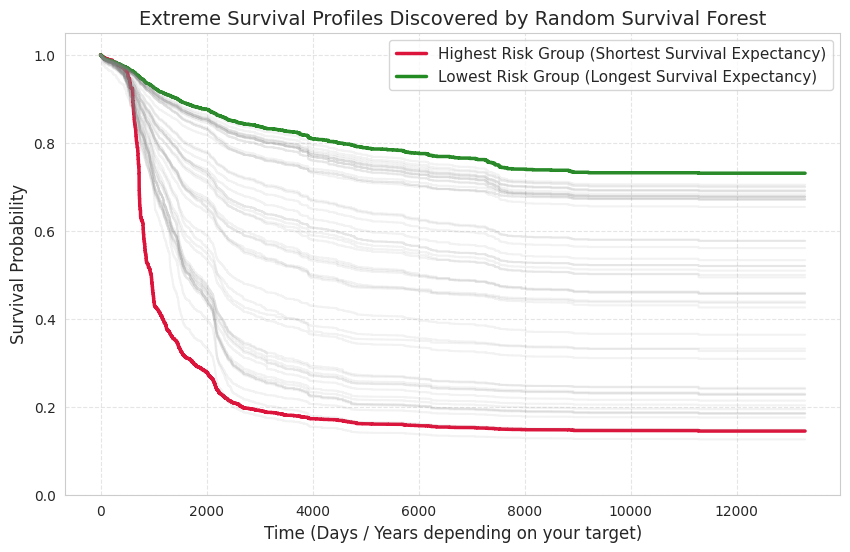

=== ХАРАКТЕРИСТИКИ ГРУППЫ ВЫСОКОГО РИСКА ===
      Perigee    Inc  DryMass
4395      498  97.36    0.284

=== ХАРАКТЕРИСТИКИ ГРУППЫ НАДЁЖНОСТИ ===
      Perigee    Inc  DryMass
2884      609  86.69    700.0


In [296]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Получаем индивидуальные кривые выживаемости для всей выборки
# Метод возвращает массив объектов StepFunction (по одному на каждый спутник)
surv_funcs = rsf.predict_survival_function(X_train)

# 2. Нам нужно оценить площадь под кривой (интеграл), чтобы найти экстремумы.
# Чем больше площадь под кривой выживаемости, тем дольше «живет» объект.
# Возьмем таймлайн (точки времени, которые выбрала модель)
time_points = surv_funcs[0].x

# Считаем среднюю ожидаемую выживаемость (интеграл) для каждого спутника
integral_survival = np.array([f(time_points).sum() for f in surv_funcs])

# 3. Находим индексы самых контрастных объектов (листьев)
idx_shortest = np.argmin(integral_survival)  # Самая быстрая деградация (смертники)
idx_longest = np.argmax(integral_survival)  # Самая высокая выживаемость (долгожители)

# 4. Строим графики Каплана-Майера для этих экстремальных групп
plt.figure(figsize=(10, 6))

# Рисуем кривую для худшего сценария
plt.step(
    time_points,
    surv_funcs[idx_shortest](time_points),
    where="post",
    color="crimson",
    linewidth=2.5,
    label="Highest Risk Group (Shortest Survival Expectancy)",
)

# Рисуем кривую для лучшего сценария
plt.step(
    time_points,
    surv_funcs[idx_longest](time_points),
    where="post",
    color="forestgreen",
    linewidth=2.5,
    label="Lowest Risk Group (Longest Survival Expectancy)",
)

# Для фона: можно пустить блеклые серые линии остальных спутников (опционально, штук 50 для массы)
for i in np.random.choice(len(surv_funcs), size=50, replace=False):
    plt.step(
        time_points,
        surv_funcs[i](time_points),
        where="post",
        color="gray",
        alpha=0.1,
    )

plt.title(
    "Extreme Survival Profiles Discovered by Random Survival Forest", fontsize=14
)
plt.xlabel("Time (Days / Years depending on your target)", fontsize=12)
plt.ylabel("Survival Probability", fontsize=12)
plt.ylim(0, 1.05)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
plt.show()

# --- БОНУС: Выводим параметры этих спутников, чтобы понять, КТО ОНИ ---
print("=== ХАРАКТЕРИСТИКИ ГРУППЫ ВЫСОКОГО РИСКА ===")
print(X_final.iloc[[idx_shortest]][["Perigee", "Inc", "DryMass"]].to_string())

print("\n=== ХАРАКТЕРИСТИКИ ГРУППЫ НАДЁЖНОСТИ ===")
print(X_final.iloc[[idx_longest]][["Perigee", "Inc", "DryMass"]].to_string())

### Ignore

In [297]:
import pandas as pd

# 1. Считаем риски для всей выборки (если еще не посчитаны)
all_risks = rsf.predict(X_train)

# Находим экстремальные значения рисков
min_risk_val = all_risks[idx_longest]
max_risk_val = all_risks[idx_shortest]

# 2. Вытаскиваем ВСЕ спутники, которые получили от модели точно такой же прогноз
# (то есть сидят в тех же самых экстремальных листьях)
best_group = X_final[all_risks == min_risk_val]
worst_group = X_final[all_risks == max_risk_val]


# 3. Функция для сборки "паспорта группы" (диапазонов)
def get_group_passport(df_group, raw_features=["Perigee", "Inc", "DryMass"]):
    passport = {}
    for col in raw_features:
        if col in df_group.columns:
            f_min = df_group[col].min()
            f_max = df_group[col].max()
            passport[col] = (
                f"{f_min:.1f} — {f_max:.1f}"
                if f_min != f_max
                else f"{f_min:.1f} (Фиксировано)"
            )

    # Для категориальных One-Hot признаков (например, Bus, Owner), если интересно,
    # можно вывести те, которые в этой группе строго равны 1
    encoded_cols = [c for c in df_group.columns if c not in raw_features]
    active_features = []
    for c in encoded_cols:
        if df_group[c].min() == 1:  # Значит у всех в группе этот признак равен 1
            active_features.append(c)

    passport["Shared Flags"] = (
        ", ".join(active_features) if active_features else "None"
    )
    passport["Total Satellites in Leaf"] = len(df_group)

    return pd.Series(passport)


# Выводим честные диапазоны
print("=== ГРАНИЦЫ ЗНАЧЕНИЙ ДЛЯ ГРУППЫ ВЫСОКОГО РИСКА (ХУДШИЙ ЛИСТ) ===")
print(get_group_passport(worst_group))

print("\n=== ГРАНИЦЫ ЗНАЧЕНИЙ ДЛЯ ГРУППЫ НАДЁЖНОСТИ (ЛУЧШИЙ ЛИСТ) ===")
print(get_group_passport(best_group))

=== ГРАНИЦЫ ЗНАЧЕНИЙ ДЛЯ ГРУППЫ ВЫСОКОГО РИСКА (ХУДШИЙ ЛИСТ) ===
Perigee                                                   498.0 (Фиксировано)
Inc                                                        97.4 (Фиксировано)
DryMass                                                     0.3 (Фиксировано)
Shared Flags                OpOrbit_LLEO/S, Launch_Site_MAHIA, Bus_Cubesat...
Total Satellites in Leaf                                                    1
dtype: object

=== ГРАНИЦЫ ЗНАЧЕНИЙ ДЛЯ ГРУППЫ НАДЁЖНОСТИ (ЛУЧШИЙ ЛИСТ) ===
Perigee                                                         606.0 — 622.0
Inc                                                               86.7 — 86.7
DryMass                                                   700.0 (Фиксировано)
Shared Flags                OpOrbit_LEO/P, Launch_Site_VS, Shape_Complex_P...
Total Satellites in Leaf                                                   49
dtype: object


In [298]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text

# 1. Получаем прогнозы риска от твоего RSF
all_risks = rsf.predict(X_train)

# 2. Помечаем топ-10% самых опасных спутников как класс "1" (Капут), остальных как "0"
cutoff = np.percentile(all_risks, 90)
y_explain = (all_risks >= cutoff).astype(int)

# 3. Обучаем простое прозрачное дерево, чтобы оно объяснило этот выбор модели
explainer_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=5)
explainer_tree.fit(X_final, y_explain)

# 4. Выводим чистые логические правила «быстрого капута»
rules = export_text(
    explainer_tree, feature_names=list(X_final.columns), max_depth=3
)

print("=== ФАКТОРЫ И ГРАНИЦЫ, ПРИВОДЯЩИЕ К БЫСТРОМУ КАПУТУ ===")
print(rules)

=== ФАКТОРЫ И ГРАНИЦЫ, ПРИВОДЯЩИЕ К БЫСТРОМУ КАПУТУ ===
|--- Owner_PLAN <= 0.50
|   |--- Bus_Cubesat_0.25U <= 0.50
|   |   |--- Bus_Cubesat_3U <= 0.50
|   |   |   |--- class: 0
|   |   |--- Bus_Cubesat_3U >  0.50
|   |   |   |--- class: 0
|   |--- Bus_Cubesat_0.25U >  0.50
|   |   |--- class: 1
|--- Owner_PLAN >  0.50
|   |--- Bus_Other_Platform <= 0.50
|   |   |--- Inc <= 97.56
|   |   |   |--- class: 1
|   |   |--- Inc >  97.56
|   |   |   |--- class: 1
|   |--- Bus_Other_Platform >  0.50
|   |   |--- class: 0



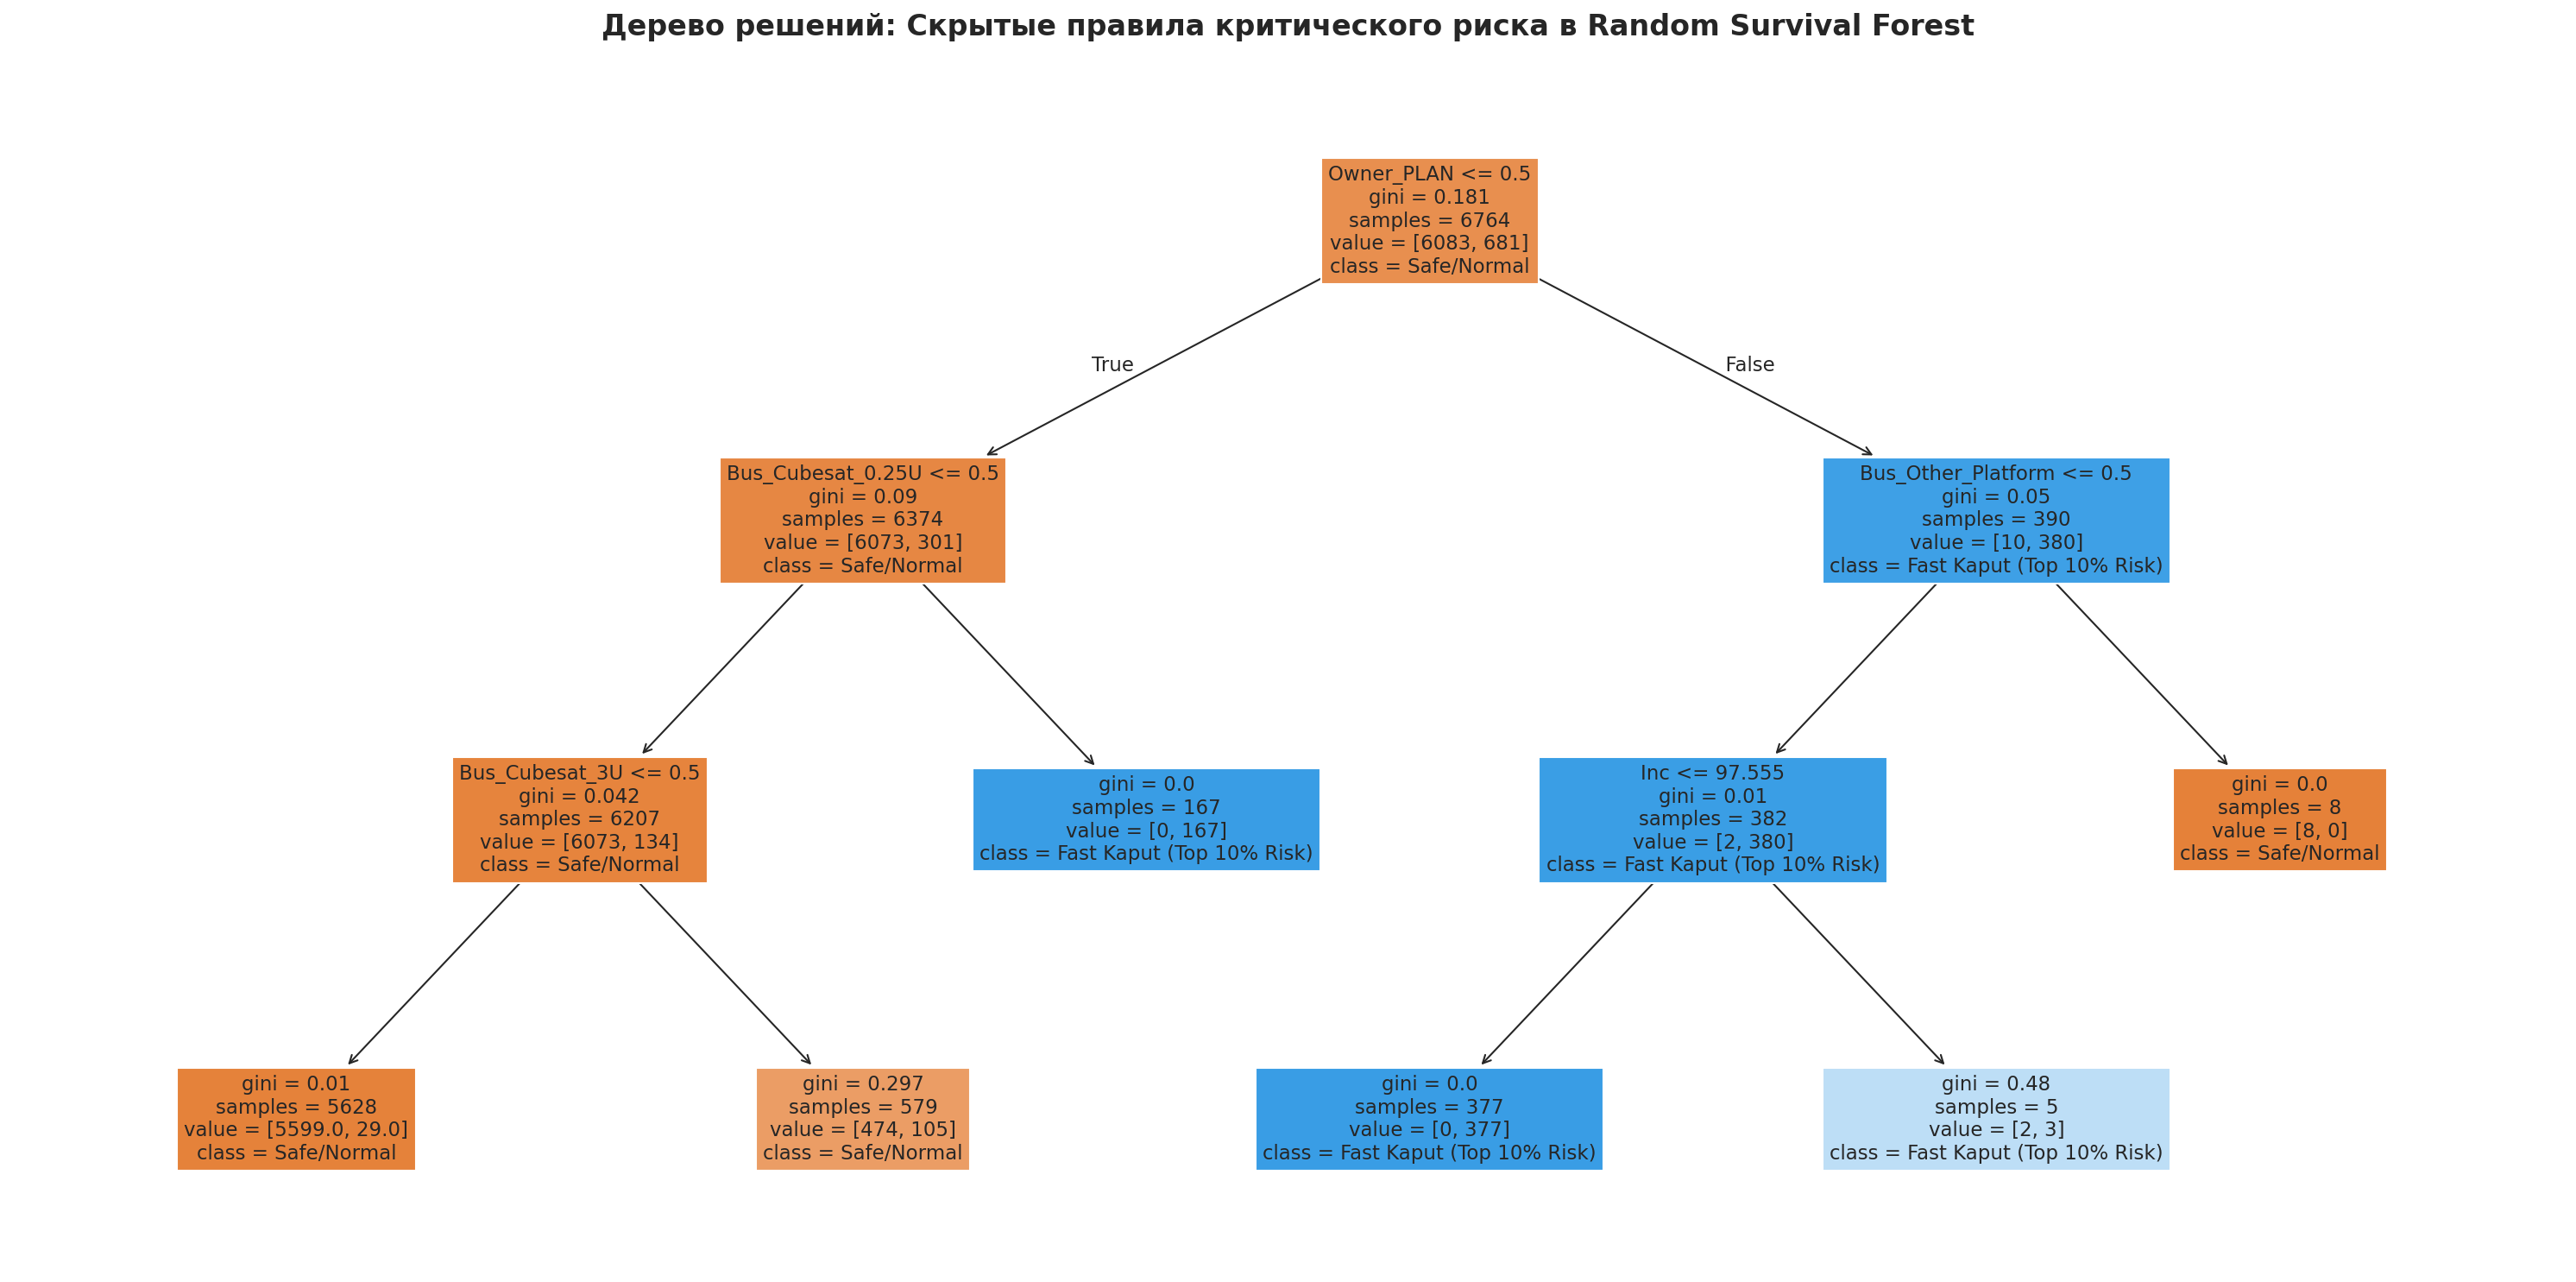

In [299]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Создаем большой холст, чтобы текст был читаемым
plt.figure(figsize=(20, 10), dpi=150)

# 2. Строим граф дерева решений
plot_tree(
    explainer_tree,
    feature_names=list(X_final.columns),
    class_names=["Safe/Normal", "Fast Kaput (Top 10% Risk)"],
    filled=True,          # Окрасит узлы: синий — безопасность, оранжевый/красный — капут
    #round_nodes=True,     # Скругленные углы для красоты
    proportion=False,     # Показывать реальное количество спутников, а не проценты
    fontsize=11
)

# 3. Добавляем заголовок и красиво выводим на экран
plt.title("Дерево решений: Скрытые правила критического риска в Random Survival Forest", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [303]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier, export_text

# 1. Считаем риски
all_risks = rsf.predict(X_train)

# 2. Определяем жесткие границы для обоих полюсов
cutoff_worst = np.percentile(all_risks, 90) # Топ-10% худших (высокий риск)
cutoff_best = np.percentile(all_risks, 10)  # Топ-10% лучших (низкий риск)

# 3. Фильтруем датасет: оставляем ТОЛЬКО экстремалы, выбрасываем серую середину
extreme_mask = (all_risks >= cutoff_worst) | (all_risks <= cutoff_best)

X_extreme = X_train[extreme_mask]
risks_extreme = all_risks[extreme_mask]

# 4. Размечаем классы: 1 — Быстрый капут, 0 — Настоящий горец (Долгожитель)
y_extreme = (risks_extreme >= cutoff_worst).astype(int)

# 5. Обучаем дерево только на контрастных данных
explainer_tree_v2 = DecisionTreeClassifier(max_depth=3, min_samples_leaf=10)
explainer_tree_v2.fit(X_extreme, y_extreme)

# 6. Выводим новые правила, которые покажут оба полюса
rules_v2 = export_text(
    explainer_tree_v2, feature_names=list(X_train.columns), max_depth=3
)

print("=== ПРАВИЛА РАЗДЕЛЕНИЯ: ГОРЦЫ (class 0) ПРОТИВ КАПУТА (class 1) ===")
print(rules_v2)

=== ПРАВИЛА РАЗДЕЛЕНИЯ: ГОРЦЫ (class 0) ПРОТИВ КАПУТА (class 1) ===
|--- DryMass <= 69.05
|   |--- class: 1
|--- DryMass >  69.05
|   |--- class: 0



## Best of the Best and Worst of the Worst

In [306]:
import numpy as np
import pandas as pd

# 1. Берем предсказания новой, здоровой модели
risks = rsf.predict(X_train)

# 2. Выделяем топ-10% истинных смертников (самый высокий риск)
worst_cutoff = np.percentile(risks, 90)
worst_cohort = X_train[risks >= worst_cutoff]

# 3. Смотрим, где сидит МЕДИАНА и интерквартильный размах (IQR) этой группы.
# Это покажет не случайную точку сплита, а плотное ядро худшей комбинации.
summary = worst_cohort[["Perigee", "DryMass", "Inc"]].describe().loc[["min", "25%", "50%", "75%", "max"]]

print("=== ЯДРО ХУДШЕЙ КОМБИНАЦИИ ФИЧ (ТОП-10% РИСКА) ===")
print(summary)
print("\n" + "="*50 + "\n")

# 4. А теперь найдем самый частый паттерн среди дискретных/категориальных фич (флагов)
# Вытаскиваем топ-5 флагов, которые чаще всего взведены у этой группы смертников
binary_cols = [col for col in X_train.columns if col not in ["Perigee", "DryMass", "Inc"]]
binary_frequencies = worst_cohort[binary_cols].mean().sort_values(ascending=False)

print("=== ТОП ФЛАГОВ, ПРИСУТСТВУЮЩИХ В ХУДШЕЙ КОМБИНАЦИИ (Доля от 0 до 1) ===")
print(len(worst_cohort))
print(binary_frequencies.head(5))

=== ЯДРО ХУДШЕЙ КОМБИНАЦИИ ФИЧ (ТОП-10% РИСКА) ===
     Perigee  DryMass    Inc
min    210.0     0.25  34.53
25%    496.0     2.16  97.44
50%    511.0     4.70  97.50
75%    519.0     5.70  97.51
max    536.0     8.10  98.23


=== ТОП ФЛАГОВ, ПРИСУТСТВУЮЩИХ В ХУДШЕЙ КОМБИНАЦИИ (Доля от 0 до 1) ===
681
Bus_Cubesat_3U           0.712188
Shape_Box_with_Panels    0.604993
Owner_PLAN               0.558003
Launch_Site_CC           0.370044
Bus_Cubesat_0.25U        0.245228
dtype: float64


In [308]:
import numpy as np
import pandas as pd

# 1. Get predictions from the new, healthy model
risks = rsf.predict(X_train)

# 2. Identify the top 10% of true long-livers (lowest risk)
best_cutoff = np.percentile(risks, 10)
best_cohort = X_train[risks <= best_cutoff]

# 3. Look at the MEDIAN and interquartile range (IQR) of this group.
# This will show not a random split point, but the dense core of the best combination.
summary = best_cohort[["Perigee", "DryMass", "Inc"]].describe().loc[["min", "25%", "50%", "75%", "max"]]

print("=== CORE OF THE BEST FEATURE COMBINATION (TOP-10% LOWEST RISK) ===")
print(summary)
print("\n" + "="*50 + "\n")

# 4. Now let's find the most common pattern among discrete/categorical features (flags)
# Extract the top-5 flags that are most frequently set for this group of long-livers
binary_cols = [col for col in X_train.columns if col not in ["Perigee", "DryMass", "Inc"]]
binary_frequencies = best_cohort[binary_cols].mean().sort_values(ascending=False)

print("=== TOP FLAGS PRESENT IN THE BEST COMBINATION (Proportion from 0 to 1) ===")
print(len(best_cohort))
print(binary_frequencies.head(5))

=== CORE OF THE BEST FEATURE COMBINATION (TOP-10% LOWEST RISK) ===
     Perigee  DryMass     Inc
min    583.0    130.0   0.000
25%    794.0    340.0   3.225
50%   1412.0    700.0  55.040
75%  35760.5   1420.0  82.600
max  36039.0   6500.0  90.000


=== TOP FLAGS PRESENT IN THE BEST COMBINATION (Proportion from 0 to 1) ===
683
Bus_Other_Platform       1.000000
Shape_Box_with_Panels    0.667643
Owner_Other_Owners       0.431918
Launch_Site_XSC          0.234261
Launch_Site_GIK-5        0.184480
dtype: float64


## Executive Summary: Extreme Survival Profiles

By isolating the top 10% highest-risk assets ("Worst") and top 10% lowest-risk assets ("Best") from the regularized RSF model predictions ($C\text{-index} = 0.795$), we mapped two distinct orbital realities.

1. "Worst" Profile: Low-Cost LEO Consumables

* The Trap: Low-altitude Sun-Synchronous Orbits (Median Perigee: 511 km, Inclination: 97.5°). Upper atmospheric drag acts as a deterministic sink.

* The Design: Standardized 3U Cubesats (71.2%) with a median mass of 4.7 kg. Over 60% deploy solar panels (Shape_Box_with_Panels), acting as an aerodynamic sail that accelerates orbital decay.

* The Drivers: Primarily commercial earth-imaging megaconstellations (Owner_PLAN / Planet Labs: 55.8%) launched via rideshares from Cape Canaveral. These are disposable assets designed to burn up rapidly post-mission.

2. "Best" Profile: Permanent Industrial Infrastructure

* The Safe Haven: Medium Earth Orbits (Median Perigee: 1,412 km for navigation) and Geostationary Orbits (up to 36,039 km for telecoms). Atmospheric drag is non-existent.

* The Design: 100% heavy industrial platforms (Bus_Other_Platform) with a median mass of 700 kg (up to 6.5 metric tons). Equipped with active propulsion, heavy shielding, and deep hardware redundancy.

* The Drivers: State-backed civilian and military infrastructure launched from China's Xichang (Launch_Site_XSC: 23.4%) and Russia's Baikonur (Launch_Site_GIK-5: 18.4%). Built to last for decades.

Key Takeaway

The model successfully bypassed categorical noise and captured the true physics of the data: separating short-lived commercial LEO constellations from indefinite, heavy MEO/GEO orbital infrastructure.

Given the high variance of surrogate decision trees and potential data leakage via space-launch clusters, standard random K-Fold cross-validation is insufficient. To ensure structural stability, the model requires validation using GroupKFold (grouped by launch mission) or a Time-Based Split to prevent the ensemble from memorizing specific commercial megaconstellation deployments